# MODMA Audio Dataset — EDA & Feature Extraction
## Group 6 | IIT Madras | BSDA4001 — Milestone 2

**Dataset:** MODMA (Multi-modal Open Dataset for Mental-disorder Analysis) — Audio Module  
**Source:** Lanzhou University Second Hospital, China (2015 collection)  
**Task:** Binary MDD classification (MDD vs. Healthy Control)  
**Role in pipeline:** Clinical speech-based depression detection fed into the multi-modal fusion model

### Dataset Structure
| Attribute | Details |
|---|---|
| Total subjects | 52 (originally 53 in paper; 1 excluded) |
| Audio files per subject | 29 WAV files (structured speech tasks) |
| Total audio files | 52 × 29 = **1,508 files** |
| Subject groups | 0201xxxx = MDD (23), 0202xxxx = HC (16), 0203xxxx = HC (13) |
| Label mapping | MDD → 1, HC → 0 (binary classification) |

### Feature Inventory (per audio file → aggregated per subject)
| Feature Group | Features | Count |
|---|---|---|
| MFCC (40 coeff.) | mean, std, min, max, median | 200 |
| Delta-MFCC (40 coeff.) | mean, std | 80 |
| Chroma (12 bins) | mean, std, min, max | 48 |
| Mel spectrogram (128 bands) | mean | 128 |
| Spectral centroid | mean, std | 2 |
| Spectral bandwidth | mean, std | 2 |
| Spectral contrast (7 bands) | mean, std | 14 |
| Spectral rolloff | mean, std | 2 |
| Spectral flatness | mean, std | 2 |
| Zero Crossing Rate | mean, std, max | 3 |
| RMS energy | mean, std, max | 3 |
| Tempo (BPM) | scalar | 1 |
| Onset strength | mean, std | 2 |
| Duration | scalar | 1 |
| **Per-file subtotal** | | **488** |
| **Per-subject (mean+std across 29 files)** | | **≈ 976** |

## Section 1 — Import Required Libraries

In [1]:
import os
import glob
import warnings
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from scipy import stats
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
from IPython.display import Audio, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

print(f"librosa   : {librosa.__version__}")
print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print("✓ All libraries loaded")

librosa   : 0.11.0
numpy     : 2.4.2
pandas    : 3.0.1
✓ All libraries loaded


## Section 2 — Dataset Configuration & Path Setup

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE      = Path(r"e:\Group-6-DS-and-AI-Lab-Project")
DATA_DIR  = BASE / "MODMA_AUDIO Datatset" / "audio_lanzhou_2015"
OUT_DIR   = BASE / "processed_data" / "modma_audio"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio processing constants ────────────────────────────────────────────────
SR         = 16000     # resample to 16 kHz (standard for speech processing)
N_MFCC     = 40        # number of MFCC coefficients
N_MELS     = 128       # mel filter banks
N_CHROMA   = 12        # chroma bins
HOP_LENGTH = 512       # hop size for STFT
N_FFT      = 2048      # FFT window size

# ── Label mapping based on MODMA subject ID prefix convention ─────────────────
# Subject ID: 0201xxxx = MDD patients, 0202xxxx = HC, 0203xxxx = HC
# Reference: MODMA paper — Wang et al. (2022), Scientific Data
GROUP_LABEL_MAP = {
    "0201": 1,   # MDD — Major Depressive Disorder
    "0202": 0,   # HC  — Healthy Control
    "0203": 0,   # HC  — Healthy Control (second batch)
}
GROUP_NAME_MAP = {
    "0201": "MDD",
    "0202": "HC",
    "0203": "HC",
}

# ── Aggregation statistics for per-file features ──────────────────────────────
STAT_FUNCS = {
    "mean"  : np.nanmean,
    "std"   : np.nanstd,
    "min"   : np.nanmin,
    "max"   : np.nanmax,
    "median": np.nanmedian,
}

print(f"Dataset root  : {DATA_DIR}")
print(f"Dataset exists: {DATA_DIR.exists()}")
print(f"Output dir    : {OUT_DIR}")
print(f"\nSample rate   : {SR} Hz")
print(f"N_MFCC        : {N_MFCC}")
print(f"N_MELS        : {N_MELS}")
print(f"N_CHROMA      : {N_CHROMA}")

Dataset root  : e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015
Dataset exists: True
Output dir    : e:\Group-6-DS-and-AI-Lab-Project\processed_data\modma_audio

Sample rate   : 16000 Hz
N_MFCC        : 40
N_MELS        : 128
N_CHROMA      : 12


## Section 3 — Dataset Structure Exploration

In [3]:
# ── Walk the full directory tree ──────────────────────────────────────────────
subject_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Total subject folders: {len(subject_dirs)}")
print("=" * 60)

# ── Count per group prefix ────────────────────────────────────────────────────
group_counts = defaultdict(list)
for s in subject_dirs:
    prefix = s.name[:4]           # e.g. "0201"
    group_counts[prefix].append(s.name)

print("\nSubjects per group:")
for prefix, sids in sorted(group_counts.items()):
    group_name = GROUP_NAME_MAP.get(prefix, "Unknown")
    label      = GROUP_LABEL_MAP.get(prefix, -1)
    print(f"  Group {prefix} ({group_name}, label={label}): {len(sids)} subjects")
    print(f"    IDs: {sids}")

# ── File count per subject ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("File counts per subject:")
summary_rows = []
for s in subject_dirs:
    wav_files = sorted(s.glob("*.wav"))
    prefix    = s.name[:4]
    summary_rows.append({
        "subject_id" : s.name,
        "group"      : GROUP_NAME_MAP.get(prefix, "Unknown"),
        "label"      : GROUP_LABEL_MAP.get(prefix, -1),
        "n_wav_files": len(wav_files),
        "files"      : [f.name for f in wav_files],
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df[["subject_id", "group", "label", "n_wav_files"]].to_string(index=False))
print(f"\nTotal WAV files in dataset: {summary_df['n_wav_files'].sum()}")
print(f"All subjects have identical file count: {summary_df['n_wav_files'].nunique() == 1}")

Total subject folders: 52

Subjects per group:
  Group 0201 (MDD, label=1): 23 subjects
    IDs: ['02010001', '02010002', '02010003', '02010004', '02010005', '02010006', '02010008', '02010009', '02010010', '02010011', '02010012', '02010013', '02010014', '02010015', '02010018', '02010022', '02010023', '02010024', '02010025', '02010034', '02010036', '02010037', '02010039']
  Group 0202 (HC, label=0): 16 subjects
    IDs: ['02020004', '02020007', '02020008', '02020010', '02020011', '02020014', '02020015', '02020016', '02020018', '02020019', '02020021', '02020022', '02020023', '02020025', '02020026', '02020027']
  Group 0203 (HC, label=0): 13 subjects
    IDs: ['02030001', '02030002', '02030004', '02030005', '02030006', '02030007', '02030008', '02030009', '02030010', '02030014', '02030015', '02030016', '02030017']

File counts per subject:
subject_id group  label  n_wav_files
  02010001   MDD      1           29
  02010002   MDD      1           29
  02010003   MDD      1           29
  02

## Section 4 — Audio File Discovery & Full Inventory

In [4]:
# ── Recursively collect every WAV file with full metadata ─────────────────────
inventory_rows = []
for subject_dir in subject_dirs:
    subject_id = subject_dir.name
    prefix     = subject_id[:4]
    group      = GROUP_NAME_MAP.get(prefix, "Unknown")
    label      = GROUP_LABEL_MAP.get(prefix, -1)

    wav_files = sorted(subject_dir.glob("*.wav"))
    for wav_path in wav_files:
        file_size_kb = wav_path.stat().st_size / 1024
        inventory_rows.append({
            "subject_id"    : subject_id,
            "group_prefix"  : prefix,
            "group"         : group,
            "label"         : label,
            "file_name"     : wav_path.name,
            "file_stem"     : wav_path.stem,         # "01" … "29"
            "segment_idx"   : int(wav_path.stem),    # 1 … 29
            "file_path"     : str(wav_path),
            "file_size_kb"  : round(file_size_kb, 2),
            "file_format"   : wav_path.suffix.lower(),
        })

inventory = pd.DataFrame(inventory_rows)
print(f"Full inventory shape : {inventory.shape}")
print(f"Columns              : {list(inventory.columns)}")
print(f"\nTotal files          : {len(inventory)}")
print(f"Unique subjects      : {inventory['subject_id'].nunique()}")
print(f"Files per subject    : {inventory.groupby('subject_id').size().unique().tolist()}")
print(f"Segment indices      : {sorted(inventory['segment_idx'].unique())}")
print(f"\nClass distribution (files):")
print(inventory["group"].value_counts().to_string())
print(f"\nFile size statistics (KB):")
print(inventory["file_size_kb"].describe().round(2).to_string())

inventory.head(10)

Full inventory shape : (1508, 10)
Columns              : ['subject_id', 'group_prefix', 'group', 'label', 'file_name', 'file_stem', 'segment_idx', 'file_path', 'file_size_kb', 'file_format']

Total files          : 1508
Unique subjects      : 52
Files per subject    : [29]
Segment indices      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]

Class distribution (files):
group
HC     841
MDD    667

File size statistics (KB):
count    1508.0000
mean     2226.5600
std      1749.0900
min       182.3200
25%      1214.5300
50%      1751.9500
75%      2585.3600
max     21360.6100


,subject_id,group_prefix,group,label,file_name,file_stem,segment_idx,file_path,file_size_kb,file_format
0,02010001,0201,MDD,1,01.wav,01,1,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,1292.1200,.wav
1,02010001,0201,MDD,1,02.wav,02,2,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,618.9900,.wav
2,02010001,0201,MDD,1,03.wav,03,3,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,258.5200,.wav
3,02010001,0201,MDD,1,04.wav,04,4,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,277.9200,.wav
4,02010001,0201,MDD,1,05.wav,05,5,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,429.2000,.wav
5,02010001,0201,MDD,1,06.wav,06,6,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,1162.9200,.wav
6,02010001,0201,MDD,1,07.wav,07,7,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,904.5200,.wav
7,02010001,0201,MDD,1,08.wav,08,8,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,1246.1000,.wav
8,02010001,0201,MDD,1,09.wav,09,9,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,878.6800,.wav
9,02010001,0201,MDD,1,10.wav,10,10,e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO D...,726.2600,.wav


## Section 5 — Audio File Loading & Playback Samples

In [5]:
# ── Load and inspect one representative file from each group ─────────────────
sample_subjects = {
    "MDD (0201)": inventory[inventory["group_prefix"] == "0201"].iloc[0],
    "HC  (0202)": inventory[inventory["group_prefix"] == "0202"].iloc[0],
    "HC  (0203)": inventory[inventory["group_prefix"] == "0203"].iloc[0],
}

loaded_samples = {}   # store (y, sr, meta) for later visualization

print("=" * 65)
print("Sample Audio File Inspection")
print("=" * 65)
for group_label, row in sample_subjects.items():
    y, sr_native = librosa.load(row["file_path"], sr=SR, mono=True)
    duration      = librosa.get_duration(y=y, sr=SR)
    loaded_samples[group_label] = (y, SR, row)

    print(f"\nGroup : {group_label}")
    print(f"  Subject   : {row['subject_id']}")
    print(f"  File      : {row['file_name']}")
    print(f"  Duration  : {duration:.2f} s")
    print(f"  SR (target): {SR} Hz")
    print(f"  Shape     : {y.shape}  — {len(y)} samples")
    print(f"  Amplitude range: [{y.min():.4f}, {y.max():.4f}]")
    print(f"  RMS energy: {np.sqrt(np.mean(y**2)):.6f}")

    display(Audio(data=y, rate=SR))

print("\n✓ Sample audio files loaded and displayed")

Sample Audio File Inspection

Group : MDD (0201)
  Subject   : 02010001
  File      : 01.wav
  Duration  : 10.00 s
  SR (target): 16000 Hz
  Shape     : (160000,)  — 160000 samples
  Amplitude range: [-0.0163, 0.0192]
  RMS energy: 0.001706



Group : HC  (0202)
  Subject   : 02020004
  File      : 01.wav
  Duration  : 18.54 s
  SR (target): 16000 Hz
  Shape     : (296692,)  — 296692 samples
  Amplitude range: [-0.0187, 0.0169]
  RMS energy: 0.002389



Group : HC  (0203)
  Subject   : 02030001
  File      : 01.wav
  Duration  : 24.57 s
  SR (target): 16000 Hz
  Shape     : (393105,)  — 393105 samples
  Amplitude range: [-0.0322, 0.0260]
  RMS energy: 0.003584



✓ Sample audio files loaded and displayed


## Section 6 — Waveform Visualization

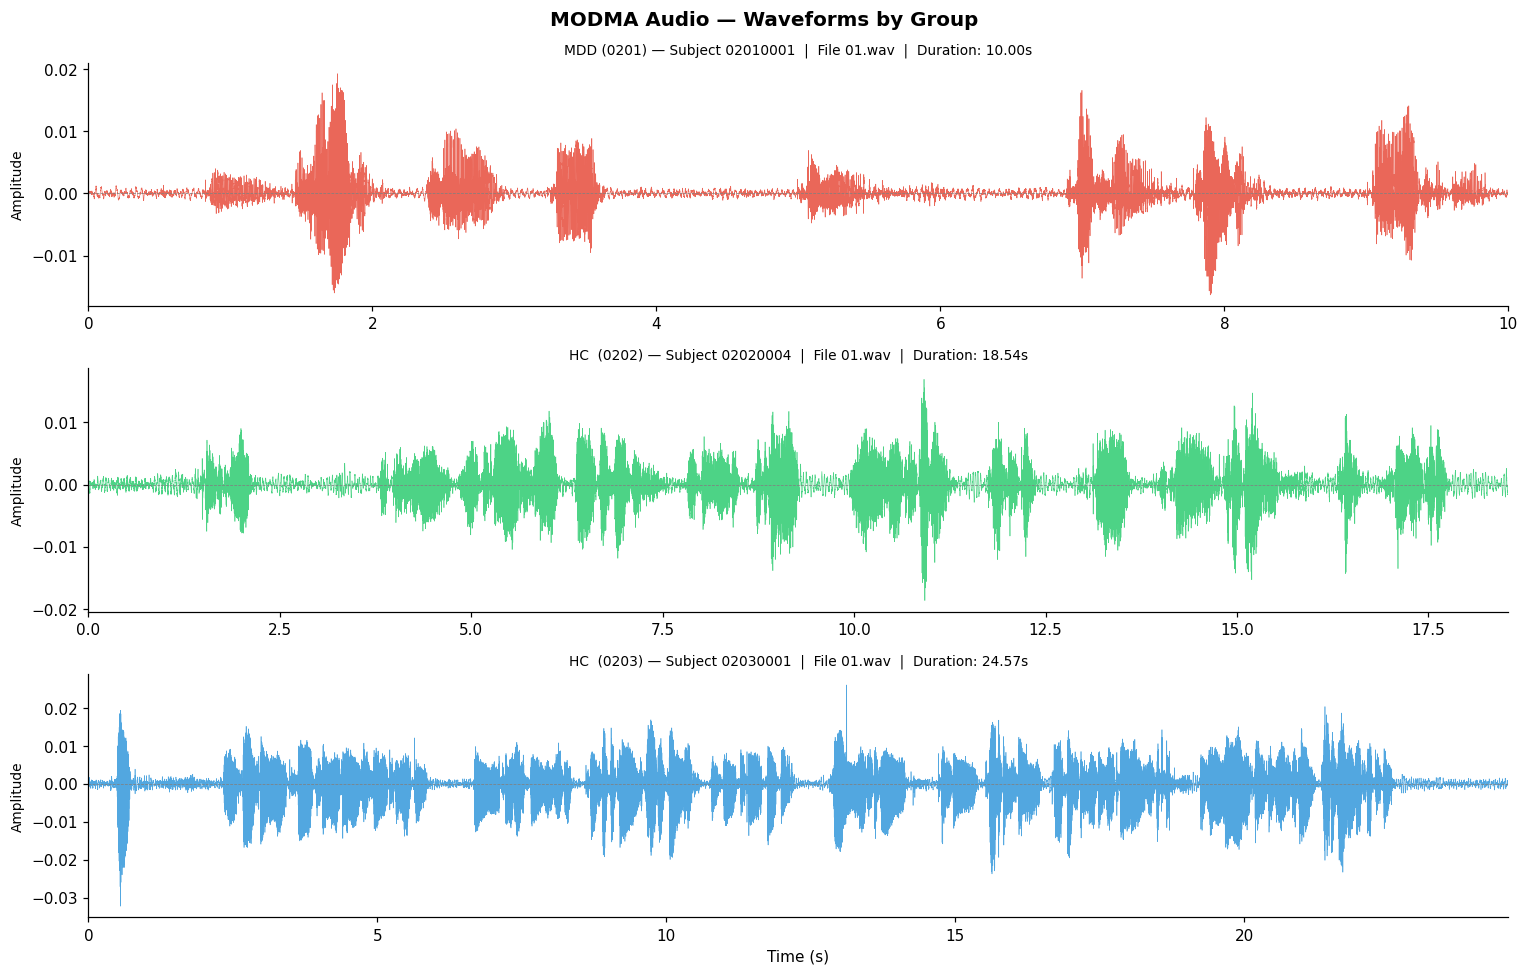

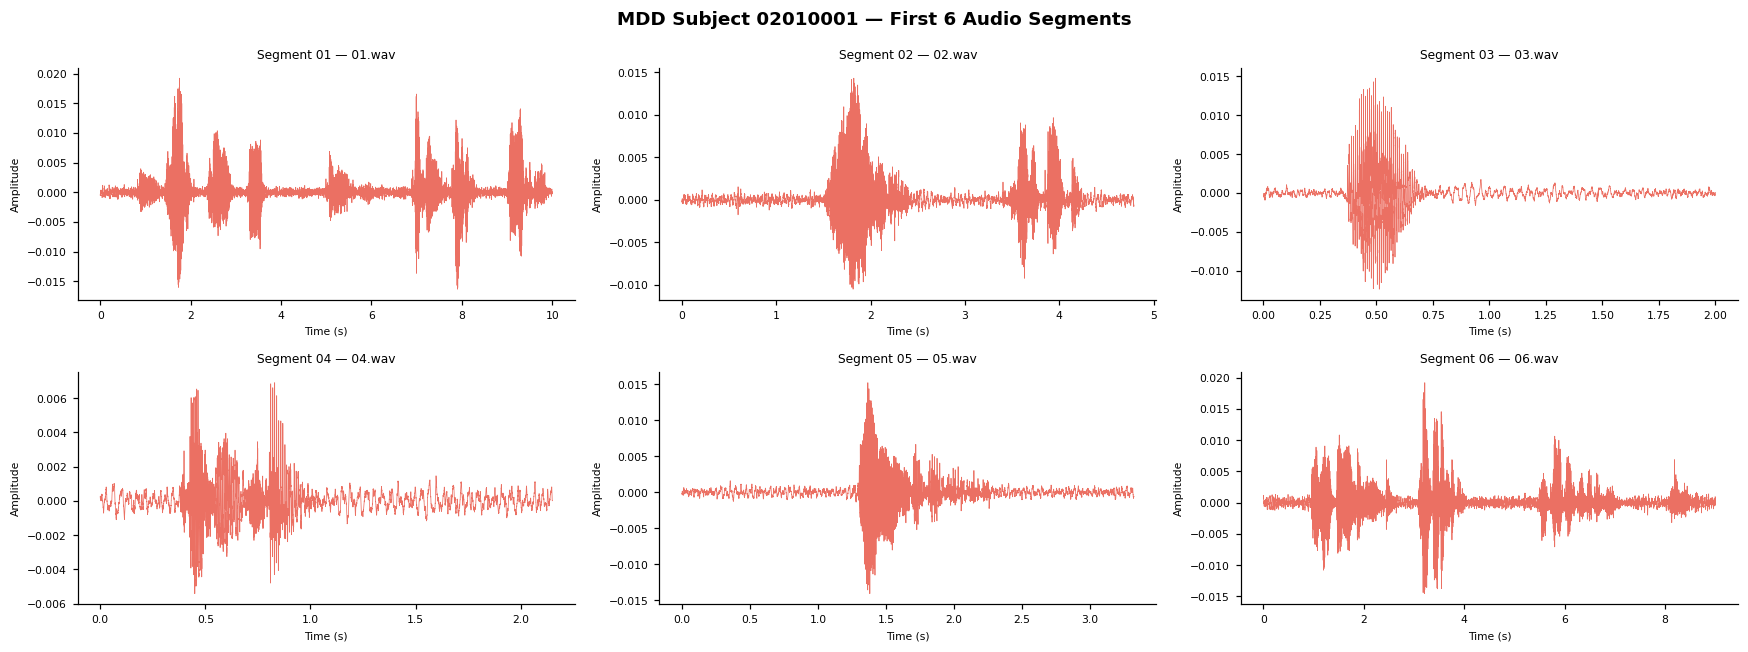

✓ Waveform plots saved.


In [6]:
# ── Waveform plots: one sample per group (MDD, HC-0202, HC-0203) ──────────────
palette = {"MDD (0201)": "#e74c3c", "HC  (0202)": "#2ecc71", "HC  (0203)": "#3498db"}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

for ax, (group_label, (y, sr, row)) in zip(axes, loaded_samples.items()):
    t = np.linspace(0, len(y) / sr, len(y))
    ax.plot(t, y, color=palette[group_label], linewidth=0.4, alpha=0.85)
    ax.set_xlim([0, t[-1]])
    ax.set_ylabel("Amplitude", fontsize=9)
    ax.set_title(f"{group_label} — Subject {row['subject_id']}  |  File {row['file_name']}"
                 f"  |  Duration: {len(y)/sr:.2f}s", fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

axes[-1].set_xlabel("Time (s)")
plt.suptitle("MODMA Audio — Waveforms by Group", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_waveforms_by_group.png", bbox_inches="tight", dpi=100)
plt.show()

# ── Also show multiple segment waveforms from one MDD subject ─────────────────
mdd_subject = inventory[inventory["group_prefix"] == "0201"].iloc[0]["subject_id"]
mdd_files   = sorted(inventory[inventory["subject_id"] == mdd_subject]["file_path"].tolist())[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
axes = axes.flatten()
for i, fpath in enumerate(mdd_files):
    y_seg, _ = librosa.load(fpath, sr=SR, mono=True)
    t        = np.linspace(0, len(y_seg) / SR, len(y_seg))
    axes[i].plot(t, y_seg, color="#e74c3c", linewidth=0.5, alpha=0.8)
    axes[i].set_title(f"Segment {i+1:02d} — {Path(fpath).name}", fontsize=8)
    axes[i].set_xlabel("Time (s)", fontsize=7)
    axes[i].set_ylabel("Amplitude", fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle(f"MDD Subject {mdd_subject} — First 6 Audio Segments", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_mdd_subject_segments.png", bbox_inches="tight", dpi=100)
plt.show()
print("✓ Waveform plots saved.")

## Section 7 — Spectrogram Analysis (STFT & Mel)

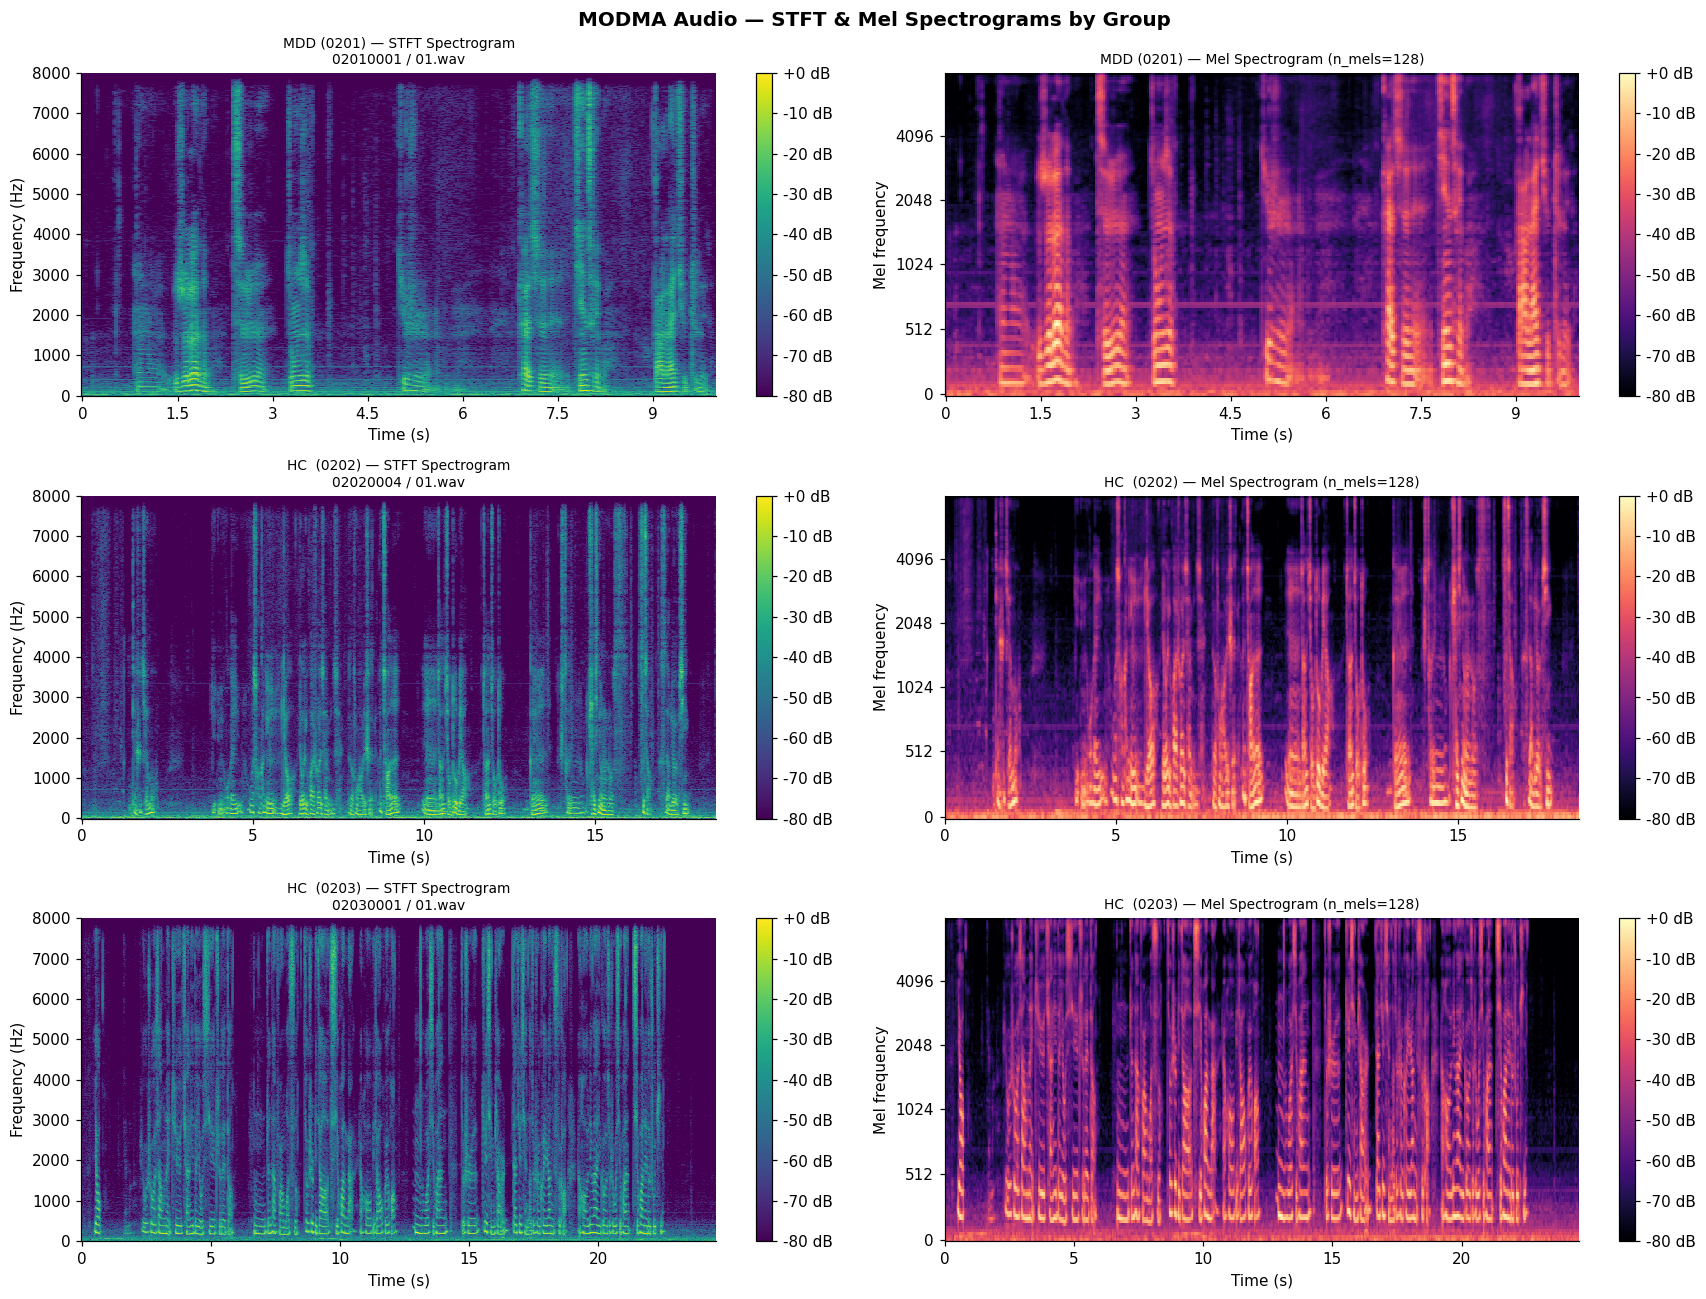

✓ Spectrogram plots saved.


In [7]:
# ── STFT + Mel spectrogram side-by-side for each group sample ─────────────────
group_list   = list(loaded_samples.keys())
group_colors = ["#e74c3c", "#2ecc71", "#3498db"]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for row_idx, (group_label, (y, sr, meta)) in enumerate(loaded_samples.items()):
    # ─ STFT spectrogram ─────────────────────────────────────────────────────
    D       = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    D_db    = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    ax_stft = axes[row_idx, 0]
    img1    = librosa.display.specshow(D_db, sr=sr, hop_length=HOP_LENGTH,
                                       x_axis="time", y_axis="hz",
                                       ax=ax_stft, cmap="viridis")
    plt.colorbar(img1, ax=ax_stft, format="%+2.0f dB")
    ax_stft.set_title(f"{group_label} — STFT Spectrogram\n{meta['subject_id']} / {meta['file_name']}", fontsize=9)
    ax_stft.set_xlabel("Time (s)"); ax_stft.set_ylabel("Frequency (Hz)")

    # ─ Mel spectrogram ─────────────────────────────────────────────────────
    mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db  = librosa.power_to_db(mel, ref=np.max)
    ax_mel  = axes[row_idx, 1]
    img2    = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH,
                                       x_axis="time", y_axis="mel",
                                       ax=ax_mel, cmap="magma")
    plt.colorbar(img2, ax=ax_mel, format="%+2.0f dB")
    ax_mel.set_title(f"{group_label} — Mel Spectrogram (n_mels={N_MELS})", fontsize=9)
    ax_mel.set_xlabel("Time (s)"); ax_mel.set_ylabel("Mel frequency")

plt.suptitle("MODMA Audio — STFT & Mel Spectrograms by Group", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_spectrograms_by_group.png", bbox_inches="tight", dpi=100)
plt.show()
print("✓ Spectrogram plots saved.")

## Section 8 — Basic Audio Statistics per Subject

In [8]:
# ── Compute basic stats for every file (fast: no feature extraction, only loads) ─
SILENCE_THRESHOLD = 0.01   # amplitude threshold for silence detection

print("Computing basic audio statistics for all 1508 files …")
basic_stat_rows = []

for _, row in tqdm(inventory.iterrows(), total=len(inventory), desc="Audio stats"):
    try:
        y, _ = librosa.load(row["file_path"], sr=SR, mono=True)
        rms_vals       = librosa.feature.rms(y=y)[0]
        silence_frames = int(np.sum(np.abs(y) < SILENCE_THRESHOLD))
        basic_stat_rows.append({
            "subject_id"    : row["subject_id"],
            "group"         : row["group"],
            "label"         : row["label"],
            "segment_idx"   : row["segment_idx"],
            "file_path"     : row["file_path"],
            "duration_s"    : librosa.get_duration(y=y, sr=SR),
            "n_samples"     : len(y),
            "mean_amplitude": float(np.mean(np.abs(y))),
            "std_amplitude" : float(np.std(y)),
            "max_amplitude" : float(np.max(np.abs(y))),
            "min_amplitude" : float(np.min(np.abs(y))),
            "rms_energy"    : float(np.sqrt(np.mean(y**2))),
            "silence_ratio" : float(silence_frames / len(y)),
        })
    except Exception as e:
        print(f"  Error on {row['file_path']}: {e}")

basic_stats = pd.DataFrame(basic_stat_rows)
print(f"\n✓ Basic stats shape: {basic_stats.shape}")

# ── Aggregate per subject ─────────────────────────────────────────────────────
subj_stats = basic_stats.groupby(["subject_id", "group", "label"]).agg(
    total_duration_s      = ("duration_s", "sum"),
    mean_duration_s       = ("duration_s", "mean"),
    std_duration_s        = ("duration_s", "std"),
    mean_rms              = ("rms_energy", "mean"),
    mean_silence_ratio    = ("silence_ratio", "mean"),
    mean_max_amplitude    = ("max_amplitude", "mean"),
    n_files               = ("duration_s", "count"),
).reset_index()

print(f"\nSubject-level aggregated stats shape: {subj_stats.shape}")
print("\nSummary statistics by group:")
print(subj_stats.groupby("group")[["total_duration_s","mean_rms","mean_silence_ratio"]].describe().round(3))
subj_stats.head(8)

Computing basic audio statistics for all 1508 files …


Audio stats:   0%|          | 0/1508 [00:00<?, ?it/s]

  Error on e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\24.wav: 
  Error on e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\25.wav: 
  Error on e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\26.wav: 
  Error on e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\27.wav: 
  Error on e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\28.wav: 

✓ Basic stats shape: (1503, 13)

Subject-level aggregated stats shape: (52, 10)

Summary statistics by group:
      total_duration_s                                                        \
                 count     mean      std      min      25%      50%      75%   
group                                                                          
HC             29.0000 496.3400 140.5290 291.5950 394.3780 490.0160 559.0750   
MDD            23.0000 499.1490 156.1580 237.5340 400.5220 

,subject_id,group,label,total_duration_s,mean_duration_s,std_duration_s,mean_rms,mean_silence_ratio,mean_max_amplitude,n_files
0,02010001,MDD,1,417.8399,14.4083,12.8508,0.0019,0.9911,0.0244,29
1,02010002,MDD,1,734.3190,25.3213,28.4707,0.0018,0.9987,0.0145,29
2,02010003,MDD,1,455.2499,15.6983,11.1688,0.0068,0.8949,0.0653,29
3,02010004,MDD,1,597.2598,24.8858,18.2181,0.0126,0.9284,0.1066,24
4,02010005,MDD,1,778.5136,26.8453,15.1225,0.0024,0.9848,0.0271,29
5,02010006,MDD,1,683.2113,23.5590,24.1672,0.0046,0.9459,0.0465,29
6,02010008,MDD,1,703.1871,24.2478,19.2608,0.0081,0.8747,0.0826,29
7,02010009,MDD,1,492.0121,16.9659,13.5041,0.0023,0.9906,0.0235,29


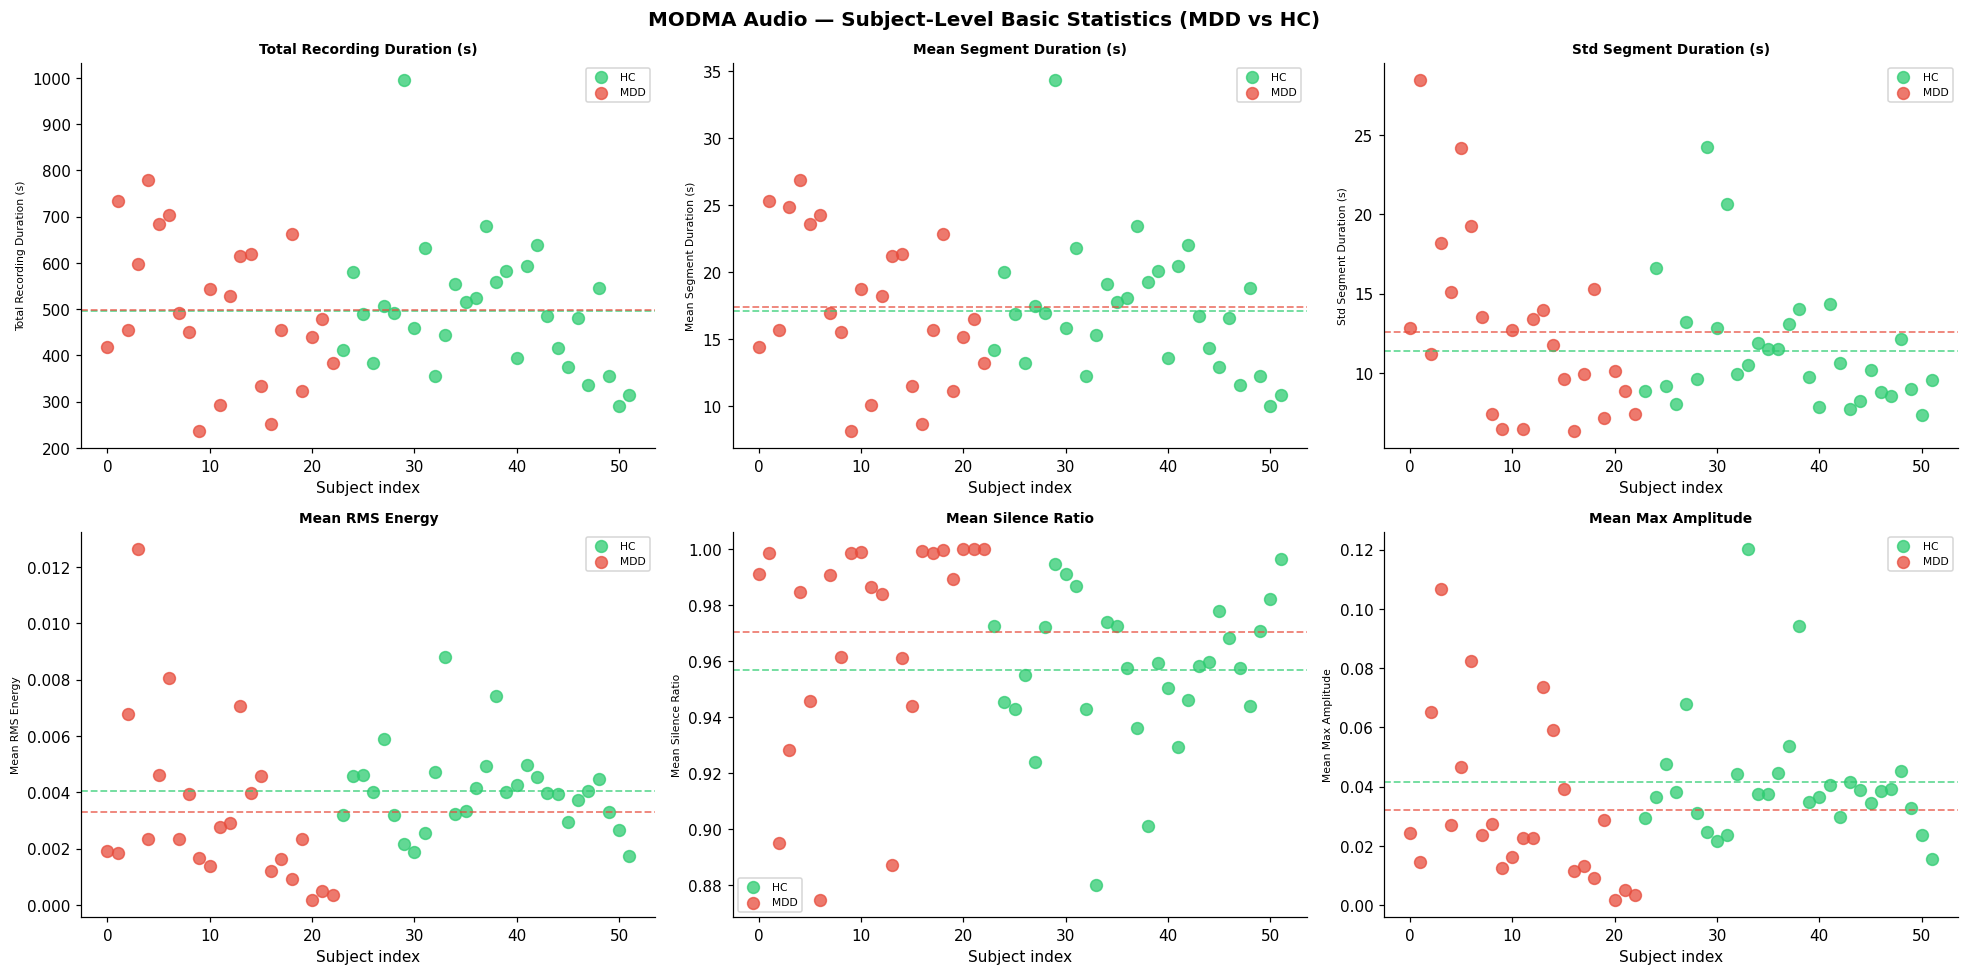

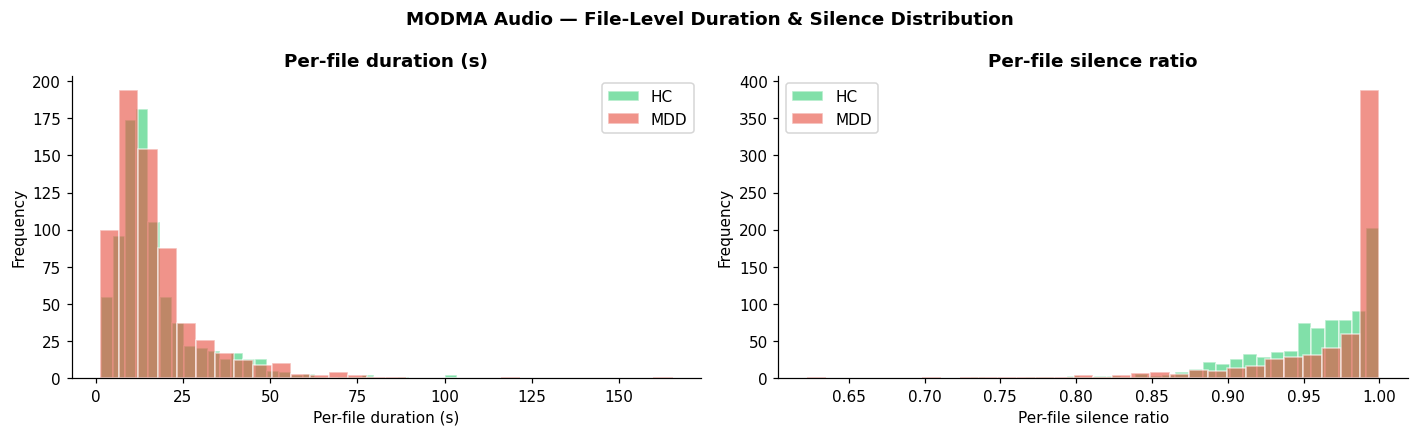

✓ Basic statistics plots saved.


In [9]:
# ── Visualize subject-level basic statistics ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
group_palette = {"MDD": "#e74c3c", "HC": "#2ecc71"}

stat_cols = [
    ("total_duration_s",   "Total Recording Duration (s)"),
    ("mean_duration_s",    "Mean Segment Duration (s)"),
    ("std_duration_s",     "Std Segment Duration (s)"),
    ("mean_rms",           "Mean RMS Energy"),
    ("mean_silence_ratio", "Mean Silence Ratio"),
    ("mean_max_amplitude", "Mean Max Amplitude"),
]

for ax, (col, title) in zip(axes, stat_cols):
    for grp, grp_df in subj_stats.groupby("group"):
        ax.scatter(grp_df.index, grp_df[col], label=grp,
                   color=group_palette.get(grp, "gray"), alpha=0.75, s=60)
    # Overlay means
    for grp, grp_df in subj_stats.groupby("group"):
        ax.axhline(grp_df[col].mean(), linestyle="--",
                   color=group_palette.get(grp, "gray"), linewidth=1.2, alpha=0.7)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Subject index"); ax.set_ylabel(title, fontsize=7)
    ax.legend(fontsize=7)

plt.suptitle("MODMA Audio — Subject-Level Basic Statistics (MDD vs HC)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_subject_basic_stats.png", bbox_inches="tight", dpi=100)
plt.show()

# ── Duration distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], "duration_s", "Per-file duration (s)"),
    (axes[1], "silence_ratio", "Per-file silence ratio"),
]:
    for grp, grp_df in basic_stats.groupby("group"):
        grp_df[col].plot.hist(ax=ax, bins=30, alpha=0.6, label=grp,
                              color=group_palette.get(grp, "gray"), edgecolor="white")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel(title); ax.legend()

plt.suptitle("MODMA Audio — File-Level Duration & Silence Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_duration_silence_hist.png", bbox_inches="tight", dpi=100)
plt.show()
print("✓ Basic statistics plots saved.")

## Section 9 — Feature Extraction: MFCC

40 MFCC coefficients are extracted per file. For each coefficient we compute **mean, std, min, max, median** across time frames → **200 MFCC features** per file.  
Additionally, **delta-MFCC** (1st-order temporal derivative) adds **80 features** (mean + std only).  
Total MFCC-family features per file: **280**.

In [10]:
def extract_mfcc_features(y: np.ndarray, sr: int) -> dict:
    """Extract MFCC + delta-MFCC features from a 1D audio array."""
    feat = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH)
    # Per-coefficient stats
    for i in range(N_MFCC):
        for stat_name, fn in STAT_FUNCS.items():
            feat[f"mfcc_{i+1:02d}_{stat_name}"] = float(fn(mfcc[i]))

    # Delta-MFCCs (temporal dynamics)
    mfcc_delta = librosa.feature.delta(mfcc, order=1)
    for i in range(N_MFCC):
        feat[f"mfcc_delta_{i+1:02d}_mean"] = float(np.nanmean(mfcc_delta[i]))
        feat[f"mfcc_delta_{i+1:02d}_std"]  = float(np.nanstd(mfcc_delta[i]))

    return feat

# ── Dry run to verify feature count ──────────────────────────────────────────
sample_y, _ = librosa.load(inventory.iloc[0]["file_path"], sr=SR)
_test_mfcc  = extract_mfcc_features(sample_y, SR)
print(f"MFCC features per file : {len(_test_mfcc)}")
print(f"  • Base MFCC  (40 × 5 stats)    : {N_MFCC * len(STAT_FUNCS)}")
print(f"  • Delta-MFCC (40 × 2 stats)    : {N_MFCC * 2}")
print(f"  Sample keys  : {list(_test_mfcc.keys())[:5]} … {list(_test_mfcc.keys())[-3:]}")
print("✓ MFCC extractor defined")

MFCC features per file : 280
  • Base MFCC  (40 × 5 stats)    : 200
  • Delta-MFCC (40 × 2 stats)    : 80
  Sample keys  : ['mfcc_01_mean', 'mfcc_01_std', 'mfcc_01_min', 'mfcc_01_max', 'mfcc_01_median'] … ['mfcc_delta_39_std', 'mfcc_delta_40_mean', 'mfcc_delta_40_std']
✓ MFCC extractor defined


## Section 10 — Feature Extraction: Chroma

12 chroma features represent the pitch-class energy distribution across an octave.  
Mean, std, min, max per bin → **48 chroma features** per file.

In [11]:
def extract_chroma_features(y: np.ndarray, sr: int) -> dict:
    """Extract chroma (pitch class energy) features."""
    feat   = {}
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=N_CHROMA,
                                         n_fft=N_FFT, hop_length=HOP_LENGTH)
    for i in range(N_CHROMA):
        for stat_name, fn in STAT_FUNCS.items():
            feat[f"chroma_{i+1:02d}_{stat_name}"] = float(fn(chroma[i]))
    return feat

_test_chroma = extract_chroma_features(sample_y, SR)
print(f"Chroma features per file : {len(_test_chroma)}")
print(f"  ({N_CHROMA} bins × {len(STAT_FUNCS)} stats = {N_CHROMA * len(STAT_FUNCS)})")
print("✓ Chroma extractor defined")

Chroma features per file : 60
  (12 bins × 5 stats = 60)
✓ Chroma extractor defined


## Section 11 — Feature Extraction: Spectral Features

Spectral features characterize the **frequency content** and **tonal distribution** of speech:  
- Mel spectrogram mean per band → **128 features**  
- Spectral centroid, bandwidth, rolloff, flatness → **mean + std each = 8 features**  
- Spectral contrast (7 bands) → **mean + std = 14 features**  
Total: **150 spectral features** per file.

In [12]:
def extract_spectral_features(y: np.ndarray, sr: int) -> dict:
    """Extract mel spectrogram, spectral centroid, bandwidth, rolloff, flatness, contrast."""
    feat = {}

    # ─ Mel spectrogram: mean per band (128 values) ──────────────────────────
    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                            n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    for i in range(N_MELS):
        feat[f"mel_{i+1:03d}_mean"] = float(np.nanmean(mel_db[i]))

    # ─ Spectral centroid ────────────────────────────────────────────────────
    sc = librosa.feature.spectral_centroid(y=y, sr=sr,
                                           n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    feat["spectral_centroid_mean"] = float(np.nanmean(sc))
    feat["spectral_centroid_std"]  = float(np.nanstd(sc))

    # ─ Spectral bandwidth ───────────────────────────────────────────────────
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr,
                                            n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    feat["spectral_bandwidth_mean"] = float(np.nanmean(sb))
    feat["spectral_bandwidth_std"]  = float(np.nanstd(sb))

    # ─ Spectral rolloff ─────────────────────────────────────────────────────
    sr_feat = librosa.feature.spectral_rolloff(y=y, sr=sr,
                                               n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    feat["spectral_rolloff_mean"] = float(np.nanmean(sr_feat))
    feat["spectral_rolloff_std"]  = float(np.nanstd(sr_feat))

    # ─ Spectral flatness ────────────────────────────────────────────────────
    sf_feat = librosa.feature.spectral_flatness(y=y, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    feat["spectral_flatness_mean"] = float(np.nanmean(sf_feat))
    feat["spectral_flatness_std"]  = float(np.nanstd(sf_feat))

    # ─ Spectral contrast (7 bands) ──────────────────────────────────────────
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr,
                                                 n_fft=N_FFT, hop_length=HOP_LENGTH)
    for i in range(contrast.shape[0]):
        feat[f"spectral_contrast_{i+1}_mean"] = float(np.nanmean(contrast[i]))
        feat[f"spectral_contrast_{i+1}_std"]  = float(np.nanstd(contrast[i]))

    return feat

_test_spec = extract_spectral_features(sample_y, SR)
print(f"Spectral features per file : {len(_test_spec)}")
print(f"  Mel bands (mean only)    : {N_MELS}")
print(f"  centroid/bandwidth/rolloff/flatness (mean+std each): 8")
print(f"  Spectral contrast (7×2)  : 14")
print("✓ Spectral extractor defined")

Spectral features per file : 150
  Mel bands (mean only)    : 128
  centroid/bandwidth/rolloff/flatness (mean+std each): 8
  Spectral contrast (7×2)  : 14
✓ Spectral extractor defined


## Section 12 — Feature Extraction: Rhythm & Tempo

In [13]:
def extract_rhythm_features(y: np.ndarray, sr: int) -> dict:
    """Extract tempo (BPM) and onset strength envelope features."""
    feat = {}

    # ─ Tempo ────────────────────────────────────────────────────────────────
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr, hop_length=HOP_LENGTH)
    feat["tempo_bpm"] = float(np.atleast_1d(tempo)[0])

    # ─ Onset strength ────────────────────────────────────────────────────────
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
    feat["onset_strength_mean"] = float(np.nanmean(onset_env))
    feat["onset_strength_std"]  = float(np.nanstd(onset_env))
    feat["onset_strength_max"]  = float(np.nanmax(onset_env))

    return feat

_test_rhythm = extract_rhythm_features(sample_y, SR)
print(f"Rhythm features per file : {len(_test_rhythm)}")
print(f"  tempo_bpm, onset_strength_mean/std/max")
print("✓ Rhythm extractor defined")

Rhythm features per file : 4
  tempo_bpm, onset_strength_mean/std/max
✓ Rhythm extractor defined


## Section 13 — Feature Extraction: Zero Crossing Rate & RMS Energy

- **ZCR** measures how often the signal crosses zero — high values indicate noisy/unvoiced speech, low values indicate voiced (depressed speech often has lower ZCR).  
- **RMS energy** captures overall loudness — depressed individuals often speak with lower energy.

In [14]:
def extract_zcr_rms_features(y: np.ndarray, sr: int) -> dict:
    """Extract Zero Crossing Rate and RMS energy features."""
    feat = {}

    # ─ Zero Crossing Rate ───────────────────────────────────────────────────
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)[0]
    feat["zcr_mean"] = float(np.nanmean(zcr))
    feat["zcr_std"]  = float(np.nanstd(zcr))
    feat["zcr_max"]  = float(np.nanmax(zcr))

    # ─ RMS Energy ───────────────────────────────────────────────────────────
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)[0]
    feat["rms_mean"] = float(np.nanmean(rms))
    feat["rms_std"]  = float(np.nanstd(rms))
    feat["rms_max"]  = float(np.nanmax(rms))

    return feat

_test_zcr = extract_zcr_rms_features(sample_y, SR)
print(f"ZCR + RMS features per file : {len(_test_zcr)}")
print(f"  ZCR : zcr_mean, zcr_std, zcr_max")
print(f"  RMS : rms_mean, rms_std, rms_max")
print("✓ ZCR + RMS extractor defined")

ZCR + RMS features per file : 6
  ZCR : zcr_mean, zcr_std, zcr_max
  RMS : rms_mean, rms_std, rms_max
✓ ZCR + RMS extractor defined


## Section 14 — Master Feature Extraction (All 1,508 Files)

This is the main extraction pipeline. For every audio file across all 52 subjects (1,508 files total),  
we run all extractors, combine results, and build a per-file feature matrix.  

> **Expected runtime:** ~15–30 min on CPU for 1,508 files. Each file takes ~0.5–1.5 s.

In [15]:
def extract_all_features(file_path: str) -> dict:
    """
    Complete feature extraction pipeline for one audio file.
    Returns a flat dict of all features (MFCC, Chroma, Spectral, Rhythm, ZCR, RMS).
    """
    y, _ = librosa.load(file_path, sr=SR, mono=True)
    feat = {}

    # ─ Duration ──────────────────────────────────────────────────────────────
    feat["duration_s"] = float(librosa.get_duration(y=y, sr=SR))

    # ─ All feature groups ────────────────────────────────────────────────────
    feat.update(extract_mfcc_features(y, SR))
    feat.update(extract_chroma_features(y, SR))
    feat.update(extract_spectral_features(y, SR))
    feat.update(extract_rhythm_features(y, SR))
    feat.update(extract_zcr_rms_features(y, SR))

    return feat

# ── Dry run to count total features per file ──────────────────────────────────
_dry = extract_all_features(inventory.iloc[0]["file_path"])
print(f"Total features per audio file : {len(_dry)}")
print(f"\nFeature group breakdown:")
groups_keys = {
    "MFCC (base)"    : [k for k in _dry if k.startswith("mfcc_") and "delta" not in k],
    "MFCC (delta)"   : [k for k in _dry if "mfcc_delta" in k],
    "Chroma"         : [k for k in _dry if k.startswith("chroma_")],
    "Mel spectrogram": [k for k in _dry if k.startswith("mel_")],
    "Spectral"       : [k for k in _dry if k.startswith("spectral_")],
    "Rhythm"         : [k for k in _dry if k.startswith("tempo_") or k.startswith("onset_")],
    "ZCR"            : [k for k in _dry if k.startswith("zcr_")],
    "RMS"            : [k for k in _dry if k.startswith("rms_")],
    "Duration"       : [k for k in _dry if k == "duration_s"],
}
total = 0
for grp, keys in groups_keys.items():
    print(f"  {grp:<20}: {len(keys):>4} features")
    total += len(keys)
print(f"  {'TOTAL':<20}: {total:>4} features")
print("\n✓ Master extractor defined. Ready to run on all 1508 files.")

Total features per audio file : 501

Feature group breakdown:
  MFCC (base)         :  200 features
  MFCC (delta)        :   80 features
  Chroma              :   60 features
  Mel spectrogram     :  128 features
  Spectral            :   22 features
  Rhythm              :    4 features
  ZCR                 :    3 features
  RMS                 :    3 features
  Duration            :    1 features
  TOTAL               :  501 features

✓ Master extractor defined. Ready to run on all 1508 files.


In [16]:
# ── Run extraction for ALL 1,508 files ────────────────────────────────────────
print(f"Starting full feature extraction for {len(inventory)} files …")
print("(This may take 15–30 minutes depending on CPU speed)\n")

file_feature_rows = []
extraction_errors = []

for _, row in tqdm(inventory.iterrows(), total=len(inventory), desc="Extracting features"):
    try:
        feats = extract_all_features(row["file_path"])
        # Attach metadata identifiers
        feats["subject_id"]  = row["subject_id"]
        feats["group"]       = row["group"]
        feats["label"]       = row["label"]
        feats["segment_idx"] = row["segment_idx"]
        feats["file_path"]   = row["file_path"]
        file_feature_rows.append(feats)
    except Exception as e:
        extraction_errors.append({"file_path": row["file_path"], "error": str(e)})
        print(f"  ⚠ Error: {row['file_path']} — {e}")

file_features_df = pd.DataFrame(file_feature_rows)
print(f"\n✓ Per-file feature matrix shape : {file_features_df.shape}")
print(f"  Rows  = individual audio files")
print(f"  Cols  = features + 5 metadata cols")
if extraction_errors:
    print(f"\n⚠  {len(extraction_errors)} files had errors:")
    for err in extraction_errors:
        print(f"   {err['file_path']}: {err['error']}")

Starting full feature extraction for 1508 files …
(This may take 15–30 minutes depending on CPU speed)



Extracting features:   0%|          | 0/1508 [00:00<?, ?it/s]

  ⚠ Error: e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\24.wav — 
  ⚠ Error: e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\25.wav — 
  ⚠ Error: e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\26.wav — 
  ⚠ Error: e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\27.wav — 
  ⚠ Error: e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\28.wav — 

✓ Per-file feature matrix shape : (1503, 506)
  Rows  = individual audio files
  Cols  = features + 5 metadata cols

⚠  5 files had errors:
   e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\24.wav: 
   e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\25.wav: 
   e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio_lanzhou_2015\02010004\26.wav: 
   e:\Group-6-DS-and-AI-Lab-Project\MODMA_AUDIO Datatset\audio

## Section 15 — Label Assignment & Class Distribution

Labels are derived from the 4-character subject ID prefix:
- `0201xxxx` → **MDD** (Major Depressive Disorder) → label = **1**
- `0202xxxx` → **HC** (Healthy Control) → label = **0**
- `0203xxxx` → **HC** (Healthy Control — second batch) → label = **0**

  MODMA Audio — Label Assignment Verification

Label mapping used:
  prefix=0201 → MDD (label=1): 23 subjects, 662 audio files
  prefix=0202 → HC (label=0): 16 subjects, 464 audio files
  prefix=0203 → HC (label=0): 13 subjects, 377 audio files

Overall class balance (files):
  HC : 841/1503 = 56.0%
  MDD : 662/1503 = 44.0%

Overall class balance (subjects):
  HC : 29/52 subjects = 55.8%
  MDD : 23/52 subjects = 44.2%


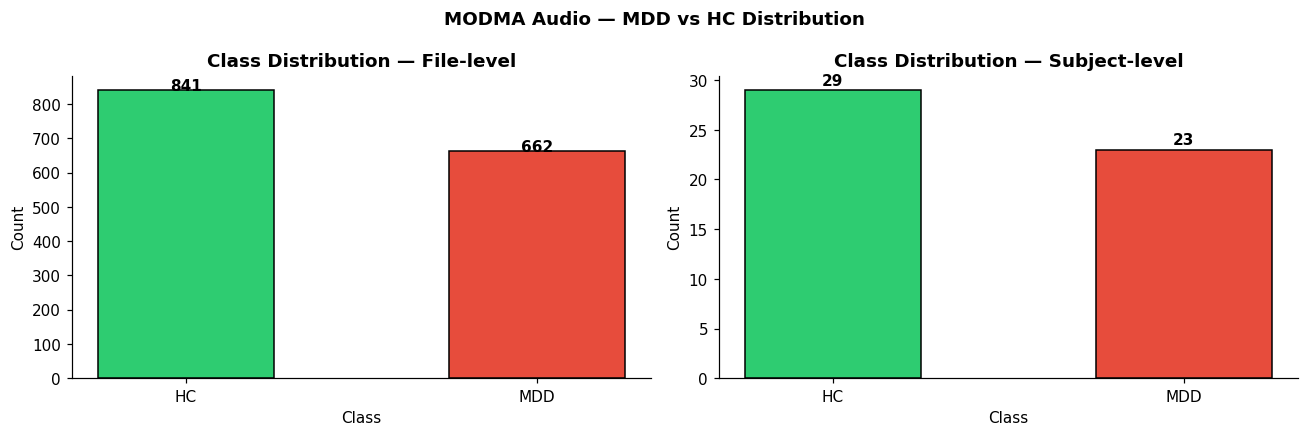

✓ Label verification complete.


In [17]:
# ── Verify labels in the feature DataFrame ────────────────────────────────────
assert "label" in file_features_df.columns, "label column missing!"
assert file_features_df["label"].notna().all(), "Some rows have NaN labels!"
assert set(file_features_df["label"].unique()).issubset({0, 1}), "Unexpected label values!"

print("=" * 55)
print("  MODMA Audio — Label Assignment Verification")
print("=" * 55)
print(f"\nLabel mapping used:")
for prefix, lbl in GROUP_LABEL_MAP.items():
    grp = GROUP_NAME_MAP[prefix]
    cnt = int((file_features_df["subject_id"].str[:4] == prefix).sum())
    n_subj = file_features_df[file_features_df["subject_id"].str[:4] == prefix]["subject_id"].nunique()
    print(f"  prefix={prefix} → {grp} (label={lbl}): {n_subj} subjects, {cnt} audio files")

print(f"\nOverall class balance (files):")
vc_files = file_features_df["label"].map({0: "HC", 1: "MDD"}).value_counts()
for cls, cnt in vc_files.items():
    pct = 100 * cnt / len(file_features_df)
    print(f"  {cls} : {cnt}/{len(file_features_df)} = {pct:.1f}%")

print(f"\nOverall class balance (subjects):")
subj_labels = file_features_df.drop_duplicates("subject_id")[["subject_id","label","group"]]
vc_subj = subj_labels["label"].map({0: "HC", 1: "MDD"}).value_counts()
for cls, cnt in vc_subj.items():
    pct = 100 * cnt / len(subj_labels)
    print(f"  {cls} : {cnt}/{len(subj_labels)} subjects = {pct:.1f}%")

# ── Class balance bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, vc) in zip(axes, [("File-level", vc_files), ("Subject-level", vc_subj)]):
    bars = ax.bar(vc.index, vc.values, color=["#2ecc71", "#e74c3c"], edgecolor="black", width=0.5)
    ax.set_title(f"Class Distribution — {title}", fontweight="bold")
    ax.set_ylabel("Count"); ax.set_xlabel("Class")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(bar.get_height())), ha="center", fontweight="bold")

plt.suptitle("MODMA Audio — MDD vs HC Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_class_distribution.png", bbox_inches="tight", dpi=100)
plt.show()
print("✓ Label verification complete.")

## Section 16 — Build Master Feature DataFrame (Subject-Level Aggregation)

Since each subject has **29 audio segments**, we aggregate the per-file features to obtain  
**one row per subject**. For each feature column, we compute **mean and std across the 29 segments**.  
This yields a clean `(52-subjects × ~976-features)` matrix ready for model training.

In [18]:
# ── Identify purely numeric feature columns (exclude metadata) ─────────────────
META_COLS = ["subject_id", "group", "label", "segment_idx", "file_path"]
feat_cols_raw = [c for c in file_features_df.columns if c not in META_COLS]

print(f"Per-file feature columns : {len(feat_cols_raw)}")

# ── Aggregate: mean + std of each feature across 29 segments per subject ──────
agg_dict = {col: ["mean", "std"] for col in feat_cols_raw}
subj_agg = (
    file_features_df
    .groupby(["subject_id", "group", "label"])
    .agg(agg_dict)
    .reset_index()
)

# Flatten MultiIndex column names: ("mfcc_01_mean", "mean") → "mfcc_01_mean_segmean"
subj_agg.columns = [
    "_".join(filter(None, [str(a), ("segmean" if b == "mean" else "segstd") if b in ("mean","std") else b]))
    if b else a
    for a, b in subj_agg.columns
]
# Clean the metadata column names (they have trailing _ from the above)
for mcol in ["subject_id", "group", "label"]:
    subj_agg.rename(columns={f"{mcol}_": mcol}, inplace=True, errors="ignore")

subj_feat_cols = [c for c in subj_agg.columns if c not in ["subject_id", "group", "label"]]

print(f"\n✓ Subject-level feature matrix shape : {subj_agg.shape}")
print(f"  Rows    = {subj_agg.shape[0]} subjects")
print(f"  Feature columns = {len(subj_feat_cols)} ({len(feat_cols_raw)} per-file × 2 stats: segmean + segstd)")
print(f"\nFirst 5 subjects:")
print(subj_agg[["subject_id","group","label"]].head(5).to_string(index=False))
subj_agg.head(4)

Per-file feature columns : 501

✓ Subject-level feature matrix shape : (52, 1005)
  Rows    = 52 subjects
  Feature columns = 1002 (501 per-file × 2 stats: segmean + segstd)

First 5 subjects:
subject_id group  label
  02010001   MDD      1
  02010002   MDD      1
  02010003   MDD      1
  02010004   MDD      1
  02010005   MDD      1


,subject_id,group,label,duration_s_segmean,duration_s_segstd,mfcc_01_mean_segmean,mfcc_01_mean_segstd,mfcc_01_std_segmean,mfcc_01_std_segstd,mfcc_01_min_segmean,mfcc_01_min_segstd,mfcc_01_max_segmean,mfcc_01_max_segstd,mfcc_01_median_segmean,mfcc_01_median_segstd,mfcc_02_mean_segmean,mfcc_02_mean_segstd,mfcc_02_std_segmean,mfcc_02_std_segstd,mfcc_02_min_segmean,mfcc_02_min_segstd,mfcc_02_max_segmean,mfcc_02_max_segstd,mfcc_02_median_segmean,mfcc_02_median_segstd,mfcc_03_mean_segmean,mfcc_03_mean_segstd,mfcc_03_std_segmean,mfcc_03_std_segstd,mfcc_03_min_segmean,mfcc_03_min_segstd,mfcc_03_max_segmean,mfcc_03_max_segstd,mfcc_03_median_segmean,mfcc_03_median_segstd,mfcc_04_mean_segmean,mfcc_04_mean_segstd,mfcc_04_std_segmean,mfcc_04_std_segstd,mfcc_04_min_segmean,mfcc_04_min_segstd,mfcc_04_max_segmean,mfcc_04_max_segstd,mfcc_04_median_segmean,mfcc_04_median_segstd,mfcc_05_mean_segmean,mfcc_05_mean_segstd,mfcc_05_std_segmean,mfcc_05_std_segstd,mfcc_05_min_segmean,mfcc_05_min_segstd,mfcc_05_max_segmean,mfcc_05_max_segstd,mfcc_05_median_segmean,mfcc_05_median_segstd,mfcc_06_mean_segmean,mfcc_06_mean_segstd,mfcc_06_std_segmean,mfcc_06_std_segstd,mfcc_06_min_segmean,mfcc_06_min_segstd,mfcc_06_max_segmean,mfcc_06_max_segstd,mfcc_06_median_segmean,mfcc_06_median_segstd,mfcc_07_mean_segmean,mfcc_07_mean_segstd,mfcc_07_std_segmean,mfcc_07_std_segstd,mfcc_07_min_segmean,mfcc_07_min_segstd,mfcc_07_max_segmean,mfcc_07_max_segstd,mfcc_07_median_segmean,mfcc_07_median_segstd,mfcc_08_mean_segmean,mfcc_08_mean_segstd,mfcc_08_std_segmean,mfcc_08_std_segstd,mfcc_08_min_segmean,mfcc_08_min_segstd,mfcc_08_max_segmean,mfcc_08_max_segstd,mfcc_08_median_segmean,mfcc_08_median_segstd,mfcc_09_mean_segmean,mfcc_09_mean_segstd,mfcc_09_std_segmean,mfcc_09_std_segstd,mfcc_09_min_segmean,mfcc_09_min_segstd,mfcc_09_max_segmean,mfcc_09_max_segstd,mfcc_09_median_segmean,mfcc_09_median_segstd,mfcc_10_mean_segmean,mfcc_10_mean_segstd,mfcc_10_std_segmean,mfcc_10_std_segstd,mfcc_10_min_segmean,mfcc_10_min_segstd,mfcc_10_max_segmean,mfcc_10_max_segstd,mfcc_10_median_segmean,mfcc_10_median_segstd,mfcc_11_mean_segmean,mfcc_11_mean_segstd,mfcc_11_std_segmean,mfcc_11_std_segstd,mfcc_11_min_segmean,mfcc_11_min_segstd,mfcc_11_max_segmean,mfcc_11_max_segstd,mfcc_11_median_segmean,mfcc_11_median_segstd,mfcc_12_mean_segmean,mfcc_12_mean_segstd,mfcc_12_std_segmean,mfcc_12_std_segstd,mfcc_12_min_segmean,mfcc_12_min_segstd,mfcc_12_max_segmean,mfcc_12_max_segstd,mfcc_12_median_segmean,mfcc_12_median_segstd,mfcc_13_mean_segmean,mfcc_13_mean_segstd,mfcc_13_std_segmean,mfcc_13_std_segstd,mfcc_13_min_segmean,mfcc_13_min_segstd,mfcc_13_max_segmean,mfcc_13_max_segstd,mfcc_13_median_segmean,mfcc_13_median_segstd,mfcc_14_mean_segmean,mfcc_14_mean_segstd,mfcc_14_std_segmean,mfcc_14_std_segstd,mfcc_14_min_segmean,mfcc_14_min_segstd,mfcc_14_max_segmean,mfcc_14_max_segstd,mfcc_14_median_segmean,mfcc_14_median_segstd,mfcc_15_mean_segmean,mfcc_15_mean_segstd,mfcc_15_std_segmean,mfcc_15_std_segstd,mfcc_15_min_segmean,mfcc_15_min_segstd,mfcc_15_max_segmean,mfcc_15_max_segstd,mfcc_15_median_segmean,mfcc_15_median_segstd,mfcc_16_mean_segmean,mfcc_16_mean_segstd,mfcc_16_std_segmean,mfcc_16_std_segstd,mfcc_16_min_segmean,mfcc_16_min_segstd,mfcc_16_max_segmean,mfcc_16_max_segstd,mfcc_16_median_segmean,mfcc_16_median_segstd,mfcc_17_mean_segmean,mfcc_17_mean_segstd,mfcc_17_std_segmean,mfcc_17_std_segstd,mfcc_17_min_segmean,mfcc_17_min_segstd,mfcc_17_max_segmean,mfcc_17_max_segstd,mfcc_17_median_segmean,mfcc_17_median_segstd,mfcc_18_mean_segmean,mfcc_18_mean_segstd,mfcc_18_std_segmean,mfcc_18_std_segstd,mfcc_18_min_segmean,mfcc_18_min_segstd,mfcc_18_max_segmean,mfcc_18_max_segstd,mfcc_18_median_segmean,mfcc_18_median_segstd,mfcc_19_mean_segmean,mfcc_19_mean_segstd,mfcc_19_std_segmean,mfcc_19_std_segstd,mfcc_19_min_segmean,mfcc_19_min_segstd,mfcc_19_max_segmean,mfcc_19_max_segstd,mfcc_19_median_segmean,mfcc_19_median_segstd,mfcc_20_mean_segmean,mfcc_20_mean_segstd,mfcc_20_std_segmean,mfcc_20_std_segstd,mf

## Section 17 — Handle Missing Values & Outliers

In [20]:

# ── NaN / Inf check ───────────────────────────────────────────────────────────
nan_counts = subj_agg[subj_feat_cols].isna().sum()
inf_counts = subj_agg[subj_feat_cols].map(lambda x: isinstance(x, float) and not np.isfinite(x)).sum()

total_nan = nan_counts.sum()
total_inf = inf_counts.sum()

print(f"Total NaN  values in feature matrix : {total_nan}")
print(f"Total Inf  values in feature matrix : {total_inf}")

if total_nan > 0:
    top_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)
    print(f"\nTop columns with NaN:\n{top_nan.head(10)}")

if total_inf > 0:
    top_inf = inf_counts[inf_counts > 0].sort_values(ascending=False)
    print(f"\nTop columns with Inf:\n{top_inf.head(10)}")

# ── Impute: fill NaN/Inf with column median ───────────────────────────────────
feat_matrix = subj_agg[subj_feat_cols].copy()
feat_matrix.replace([np.inf, -np.inf], np.nan, inplace=True)
col_medians = feat_matrix.median()
feat_matrix.fillna(col_medians, inplace=True)

remaining_nan = feat_matrix.isna().sum().sum()
print(f"\n✓ After imputation: {remaining_nan} NaN values remain")
print(f"  Feature matrix ready: {feat_matrix.shape[0]} subjects × {feat_matrix.shape[1]} features")


Total NaN  values in feature matrix : 0
Total Inf  values in feature matrix : 0

✓ After imputation: 0 NaN values remain
  Feature matrix ready: 52 subjects × 1002 features


## Section 18 — Train / Val / Test Split (Subject-Level, Stratified)

Since the dataset is **small (52 subjects)**, we perform a **subject-level stratified split**  
to ensure no data leakage (a subject's files cannot appear in both train and test).

| Split | Size | Ratio |
|---|---|---|
| Train | ~36 subjects | ~70% |
| Val   | ~8 subjects  | ~15% |
| Test  | ~8 subjects  | ~15% |

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

RANDOM_SEED = 42

# ── Stratified split: 70% train, 15% val, 15% test (subject-level) ────────────
X_meta   = subj_agg[["subject_id", "group", "label"]].copy()
y_labels = subj_agg["label"].values

# Step 1: Split off 30% (val + test) from 70% train
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
train_idx, temp_idx = next(sss1.split(X_meta, y_labels))

# Step 2: Split the 30% temp into 50/50 val and test (= 15% each)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
val_idx, test_idx = next(sss2.split(X_meta.iloc[temp_idx], y_labels[temp_idx]))
val_idx  = temp_idx[val_idx]
test_idx = temp_idx[test_idx]

# Assign split labels
subj_agg["split"] = "train"
subj_agg.iloc[val_idx,  subj_agg.columns.get_loc("split")] = "val"
subj_agg.iloc[test_idx, subj_agg.columns.get_loc("split")] = "test"

print("=" * 55)
print("  MODMA Audio — Subject-Level Split Summary")
print("=" * 55)
for split_name in ["train", "val", "test"]:
    sdf = subj_agg[subj_agg["split"] == split_name]
    mdd_n = int((sdf["label"] == 1).sum())
    hc_n  = int((sdf["label"] == 0).sum())
    print(f"\n  {split_name.upper():5} : {len(sdf):3} subjects  — MDD={mdd_n}, HC={hc_n}")
    print(f"    {sdf['subject_id'].tolist()}")

# ── Save split mapping ────────────────────────────────────────────────────────
split_map = subj_agg[["subject_id", "group", "label", "split"]].copy()
split_map.to_csv(OUT_DIR / "modma_audio_subject_splits.csv", index=False)
print(f"\n✓ Split mapping saved → modma_audio_subject_splits.csv")

  MODMA Audio — Subject-Level Split Summary

  TRAIN :  36 subjects  — MDD=16, HC=20
    ['02010001', '02010002', '02010004', '02010005', '02010006', '02010008', '02010009', '02010010', '02010012', '02010014', '02010015', '02010023', '02010024', '02010034', '02010037', '02010039', '02020004', '02020007', '02020008', '02020010', '02020011', '02020014', '02020018', '02020019', '02020022', '02020023', '02020025', '02020027', '02030001', '02030002', '02030007', '02030008', '02030009', '02030010', '02030015', '02030016']

  VAL   :   8 subjects  — MDD=4, HC=4
    ['02010003', '02010013', '02010022', '02010036', '02020015', '02020021', '02030004', '02030005']

  TEST  :   8 subjects  — MDD=3, HC=5
    ['02010011', '02010018', '02010025', '02020016', '02020026', '02030006', '02030014', '02030017']

✓ Split mapping saved → modma_audio_subject_splits.csv


## Section 19 — Feature Normalization & Scaling (Fit on Train Only)

In [22]:
# ── Partition subject-level arrays by split ───────────────────────────────────
train_mask = subj_agg["split"] == "train"
val_mask   = subj_agg["split"] == "val"
test_mask  = subj_agg["split"] == "test"

X_train_raw = subj_agg.loc[train_mask, subj_feat_cols].values.astype(np.float64)
X_val_raw   = subj_agg.loc[val_mask,   subj_feat_cols].values.astype(np.float64)
X_test_raw  = subj_agg.loc[test_mask,  subj_feat_cols].values.astype(np.float64)

y_train = subj_agg.loc[train_mask, "label"].values.astype(np.int32)
y_val   = subj_agg.loc[val_mask,   "label"].values.astype(np.int32)
y_test  = subj_agg.loc[test_mask,  "label"].values.astype(np.int32)

# ── Final safety: replace any residual NaN/Inf with training medians ──────────
for X in (X_train_raw, X_val_raw, X_test_raw):
    X[~np.isfinite(X)] = np.nan

train_medians = np.nanmedian(X_train_raw, axis=0)
for X in (X_train_raw, X_val_raw, X_test_raw):
    nan_mask = np.isnan(X)
    if nan_mask.any():
        X[nan_mask] = np.take(train_medians, np.where(nan_mask)[1])

# ── Fit StandardScaler on TRAIN only — no data leakage ────────────────────────
scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = scaler.transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print(f"✓ Scaler fitted on {X_train_raw.shape[0]} training subjects only (no leakage)")
print(f"\nArray shapes:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"\nClass distribution:")
for split_name, y_arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    mdd = int((y_arr == 1).sum()); hc = int((y_arr == 0).sum())
    print(f"  {split_name:5} : MDD={mdd}, HC={hc}")

✓ Scaler fitted on 36 training subjects only (no leakage)

Array shapes:
  X_train : (36, 1002)   y_train : (36,)
  X_val   : (8, 1002)     y_val   : (8,)
  X_test  : (8, 1002)    y_test  : (8,)

Class distribution:
  train : MDD=16, HC=20
  val   : MDD=4, HC=4
  test  : MDD=3, HC=5


## Section 20 — EDA: Feature Distributions by Class (MDD vs HC)

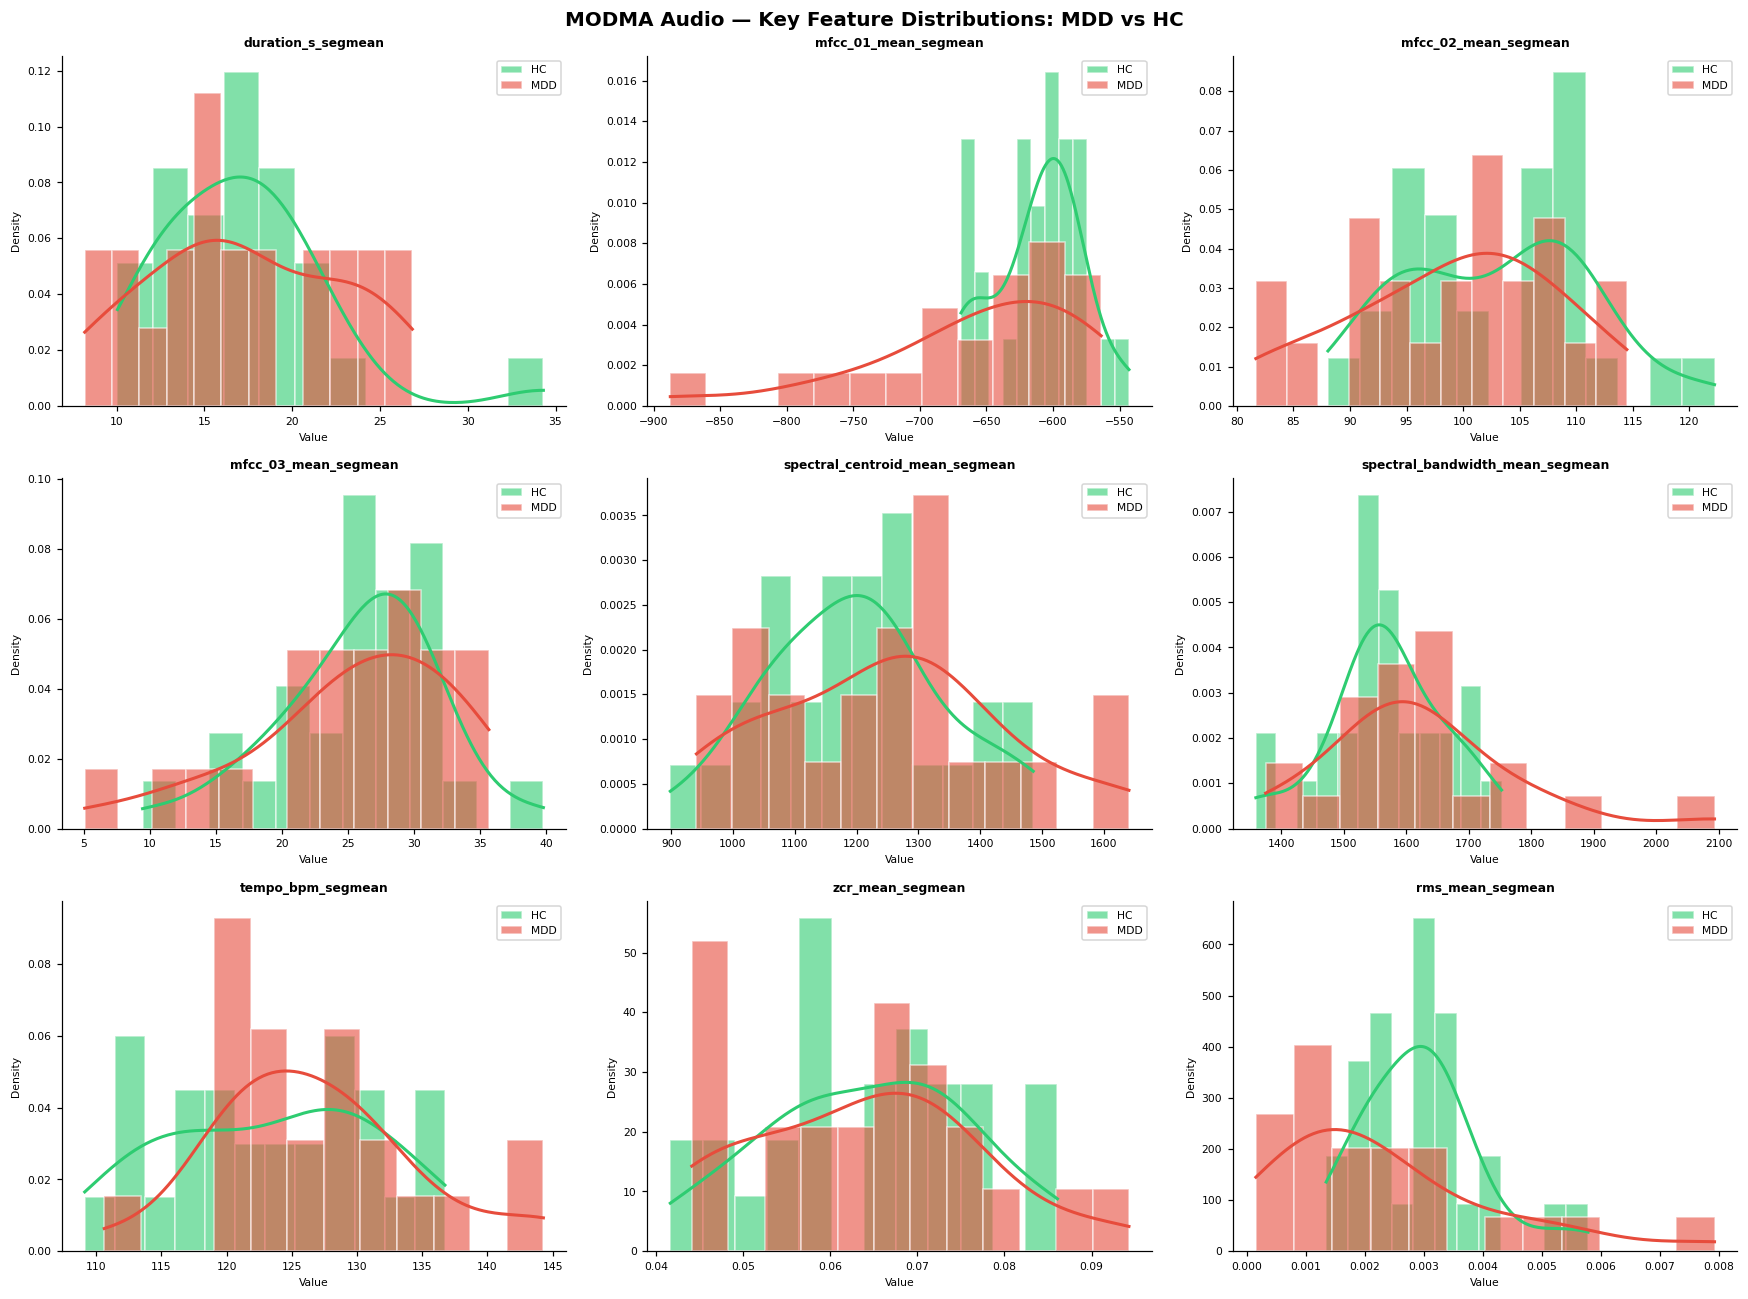

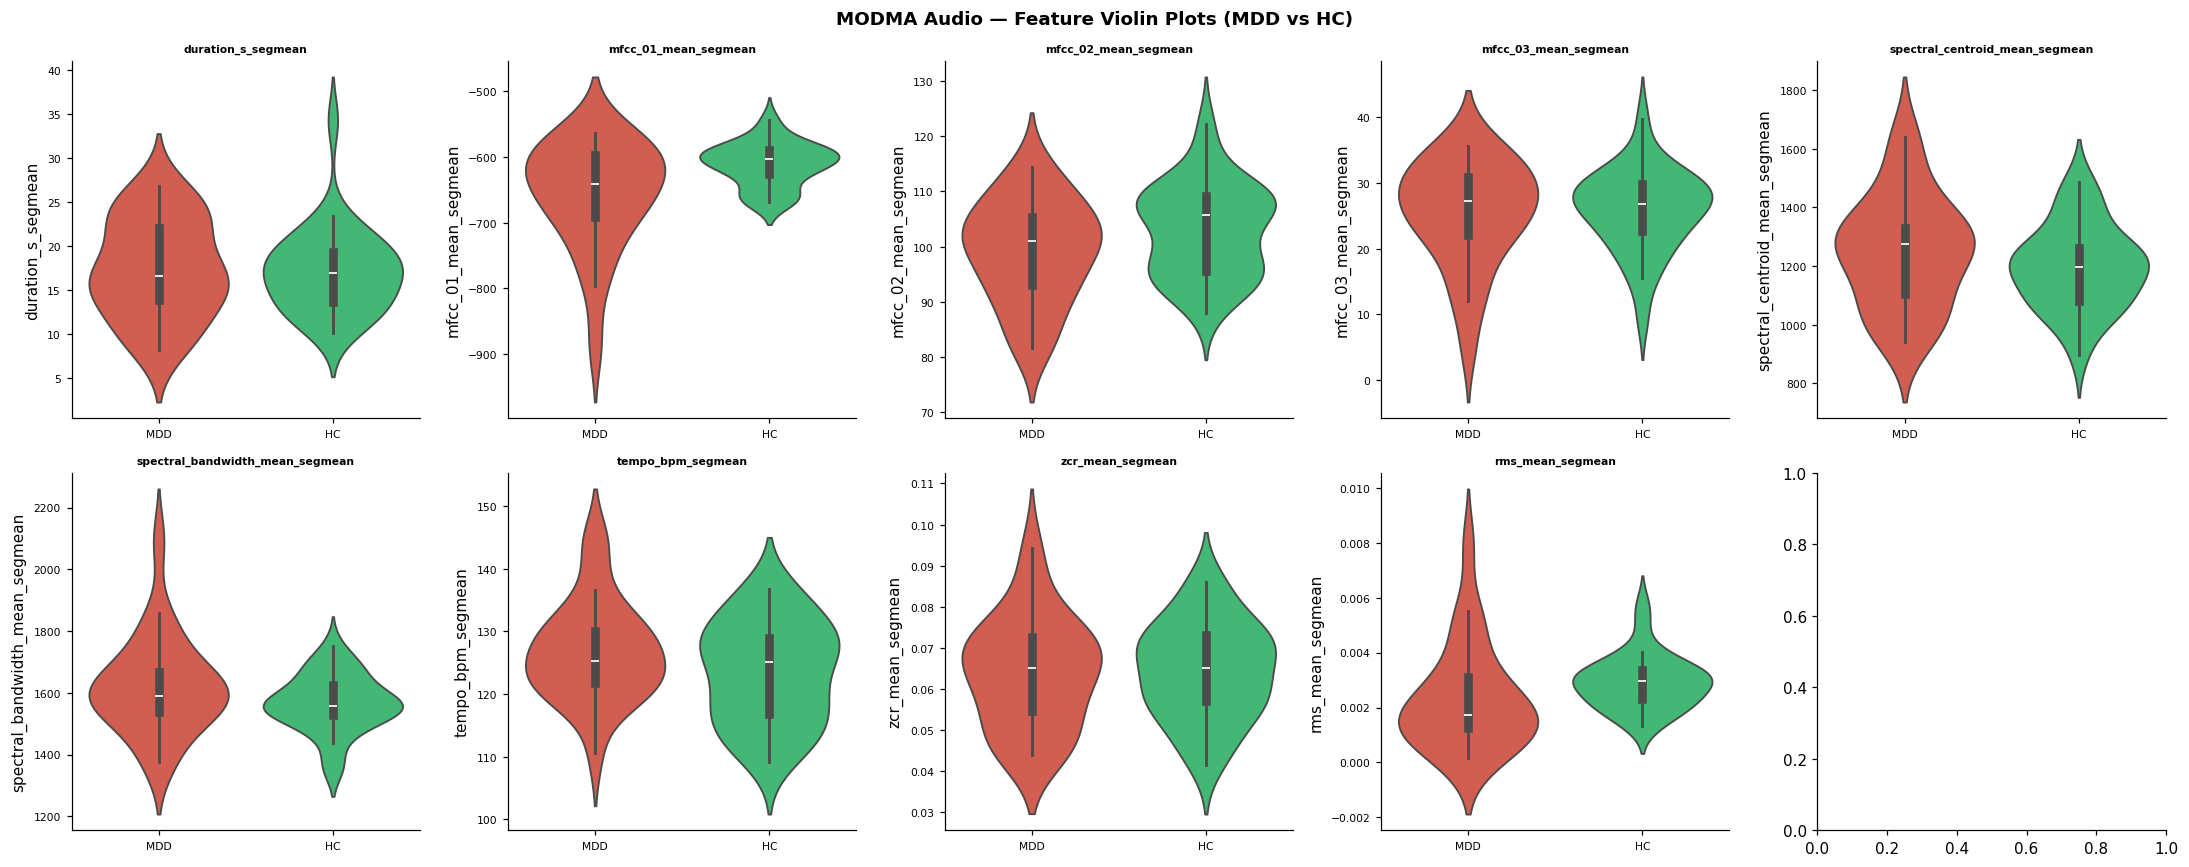

✓ Feature distribution plots saved.


In [23]:
# ── Select representative key features for visualisation ─────────────────────
key_feat_prefixes = [
    "mfcc_01_mean_segmean",
    "mfcc_02_mean_segmean",
    "mfcc_03_mean_segmean",
    "spectral_centroid_mean_segmean",
    "spectral_bandwidth_mean_segmean",
    "rms_mean_segmean",
    "zcr_mean_segmean",
    "tempo_bpm_segmean",
    "duration_s_segmean",
]
# Resolve to actual column names (handle slight naming drift)
key_feats = [c for c in subj_feat_cols if any(c.startswith(p) or c == p for p in key_feat_prefixes)][:9]

# If some weren't found, fill from available columns
if len(key_feats) < 9:
    extras = [c for c in subj_feat_cols if c not in key_feats]
    key_feats += extras[:9-len(key_feats)]

eda_df = subj_agg[["subject_id", "group", "label"] + key_feats].copy()
eda_df["class"] = eda_df["label"].map({1: "MDD", 0: "HC"})

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
class_pal = {"MDD": "#e74c3c", "HC": "#2ecc71"}

for i, feat in enumerate(key_feats):
    ax = axes[i]
    for cls_label, cls_df in eda_df.groupby("class"):
        vals = cls_df[feat].dropna()
        vals.plot.hist(ax=ax, bins=12, alpha=0.6, label=cls_label,
                       color=class_pal[cls_label], edgecolor="white", density=True)
        # KDE overlay
        from scipy.stats import gaussian_kde
        if len(vals) > 2:
            kde_x = np.linspace(vals.min(), vals.max(), 200)
            kde   = gaussian_kde(vals)
            ax.plot(kde_x, kde(kde_x), color=class_pal[cls_label], linewidth=2)

    ax.set_title(feat, fontsize=8, fontweight="bold")
    ax.set_xlabel("Value", fontsize=7); ax.set_ylabel("Density", fontsize=7)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)

plt.suptitle("MODMA Audio — Key Feature Distributions: MDD vs HC", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_feature_distributions_mdd_vs_hc.png", bbox_inches="tight", dpi=100)
plt.show()

# ── Violin plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(key_feats[:10]):
    ax = axes[i] if i < len(axes) else None
    if ax is None:
        break
    sns.violinplot(data=eda_df, x="class", y=feat, palette=class_pal,
                   inner="box", ax=ax, order=["MDD","HC"])
    ax.set_title(feat, fontsize=7, fontweight="bold")
    ax.set_xlabel(""); ax.tick_params(labelsize=7)

plt.suptitle("MODMA Audio — Feature Violin Plots (MDD vs HC)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_feature_violins.png", bbox_inches="tight", dpi=100)
plt.show()
print("✓ Feature distribution plots saved.")

Total features tested   : 1002
Significant (p<0.05)    : 110

Top 20 most discriminative features (ANOVA F-test):
                   feature  F_statistic  p_value
       mfcc_10_min_segmean      24.4341   0.0000
 mfcc_delta_11_std_segmean      22.9187   0.0000
 mfcc_delta_01_std_segmean      18.1232   0.0001
 mfcc_delta_13_std_segmean      17.1129   0.0001
       mfcc_10_std_segmean      15.7908   0.0002
       mfcc_13_std_segmean      15.3546   0.0003
 mfcc_delta_10_std_segmean      15.0170   0.0003
      mfcc_10_mean_segmean      14.9194   0.0003
 mfcc_delta_08_std_segmean      13.2466   0.0006
    mfcc_10_median_segmean      12.4363   0.0009
       mfcc_11_std_segmean      11.5236   0.0014
 mfcc_delta_04_std_segmean      11.1148   0.0016
onset_strength_std_segmean      10.8893   0.0018
 mfcc_delta_15_std_segmean      10.4852   0.0021
       mfcc_04_std_segmean      10.2911   0.0023
       mfcc_08_std_segmean      10.1785   0.0025
 mfcc_delta_05_std_segmean      10.1200   0.0025
    

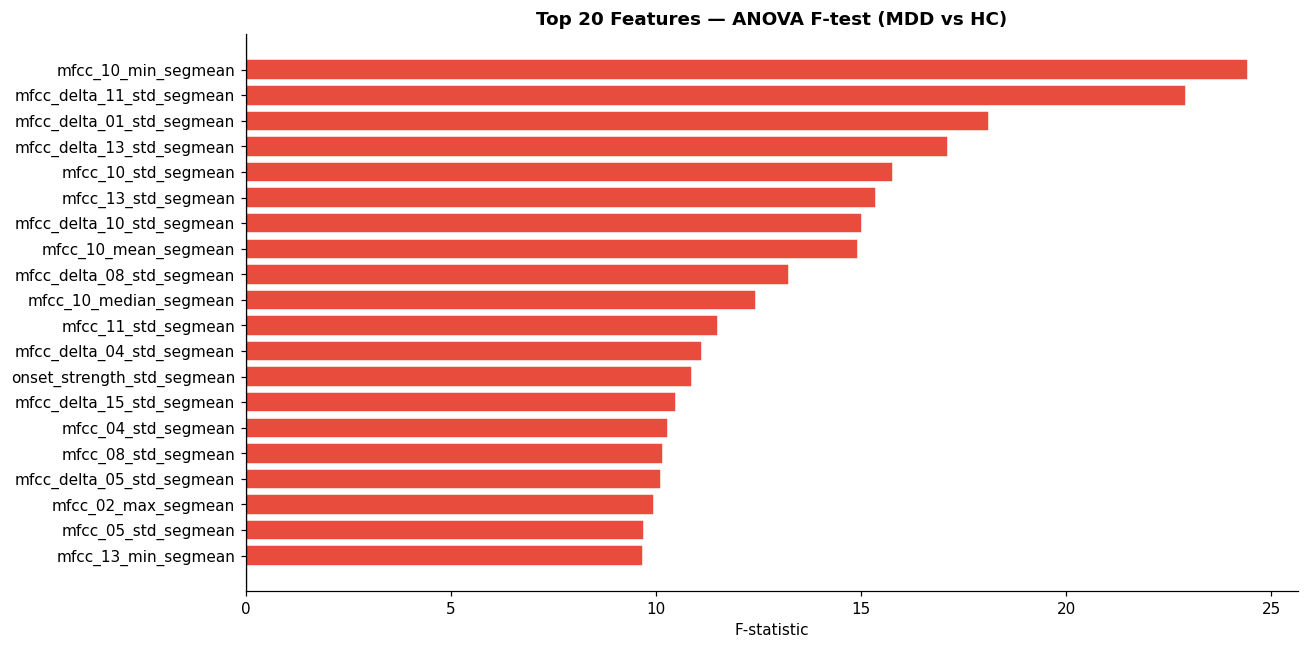

✓ ANOVA feature ranking plot saved.


In [24]:
# ── ANOVA F-test: which features differ significantly between MDD and HC ──────
from scipy.stats import f_oneway

mdd_df_all = subj_agg[subj_agg["label"] == 1]
hc_df_all  = subj_agg[subj_agg["label"] == 0]

anova_rows = []
for feat in subj_feat_cols:
    arr_mdd = mdd_df_all[feat].dropna().values
    arr_hc  = hc_df_all[feat].dropna().values
    if len(arr_mdd) > 1 and len(arr_hc) > 1:
        F, p = f_oneway(arr_mdd, arr_hc)
        anova_rows.append({"feature": feat, "F_statistic": F, "p_value": p})

anova_df = pd.DataFrame(anova_rows).sort_values("p_value")
sig_df   = anova_df[anova_df["p_value"] < 0.05]

print(f"Total features tested   : {len(anova_df)}")
print(f"Significant (p<0.05)    : {len(sig_df)}")
print(f"\nTop 20 most discriminative features (ANOVA F-test):")
print(anova_df.head(20).to_string(index=False))

# ── Top-20 significant feature bar chart ──────────────────────────────────────
top20 = anova_df.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in top20["p_value"]]
ax.barh(top20["feature"][::-1], top20["F_statistic"][::-1], color=colors[::-1], edgecolor="white")
ax.set_xlabel("F-statistic"); ax.set_title("Top 20 Features — ANOVA F-test (MDD vs HC)", fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_anova_top20_features.png", bbox_inches="tight", dpi=100)
plt.show()
print("✓ ANOVA feature ranking plot saved.")

## Section 21 — Correlation Heatmap of Features

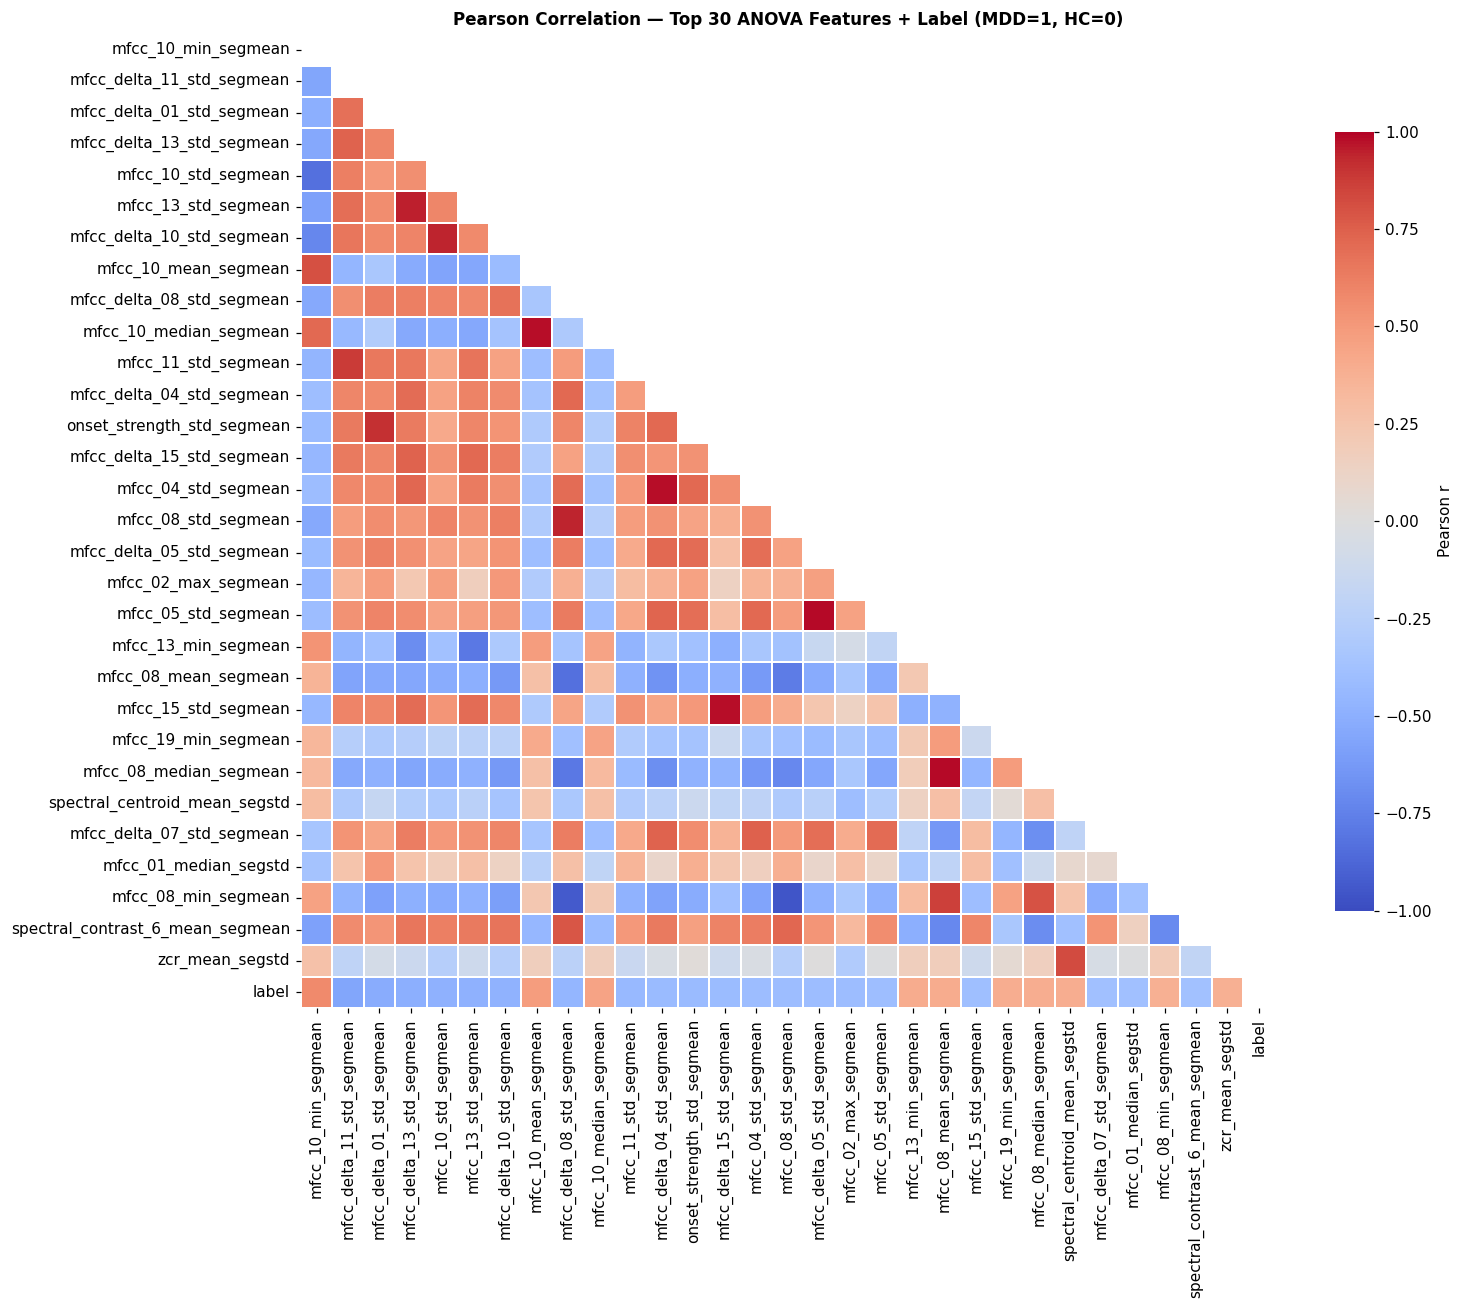

Top 20 features most correlated with label (MDD/HC):
mfcc_10_min_segmean          0.5729
mfcc_delta_11_std_segmean    0.5606
mfcc_delta_01_std_segmean    0.5158
mfcc_delta_13_std_segmean    0.5050
mfcc_10_std_segmean          0.4899
mfcc_13_std_segmean          0.4847
mfcc_delta_10_std_segmean    0.4806
mfcc_10_mean_segmean         0.4794
mfcc_delta_08_std_segmean    0.4576
mfcc_10_median_segmean       0.4463
mfcc_11_std_segmean          0.4328
mfcc_delta_04_std_segmean    0.4265
onset_strength_std_segmean   0.4229
mfcc_delta_15_std_segmean    0.4164
mfcc_04_std_segmean          0.4131
mfcc_08_std_segmean          0.4113
mfcc_delta_05_std_segmean    0.4103
mfcc_02_max_segmean          0.4075
mfcc_05_std_segmean          0.4033
mfcc_13_min_segmean          0.4029

✓ Correlation heatmap saved.


In [25]:
# ── Correlation heatmap: use top-30 ANOVA-ranked features ─────────────────────
top_features = anova_df.head(30)["feature"].tolist()
corr_df      = subj_agg[top_features + ["label"]].copy()
corr_df["label"] = corr_df["label"].astype(float)
corr_matrix  = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap="coolwarm",
    center=0, ax=ax, linewidths=0.2, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)
ax.set_title("Pearson Correlation — Top 30 ANOVA Features + Label (MDD=1, HC=0)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "modma_correlation_heatmap.png", bbox_inches="tight", dpi=100)
plt.show()

# ── Print top 20 most correlated feature pairs with the label ─────────────────
label_corr = corr_matrix["label"].drop("label").abs().sort_values(ascending=False)
print("Top 20 features most correlated with label (MDD/HC):")
print(label_corr.head(20).round(4).to_string())
print("\n✓ Correlation heatmap saved.")

## Section 22 — PCA Visualization (2D & 3D)

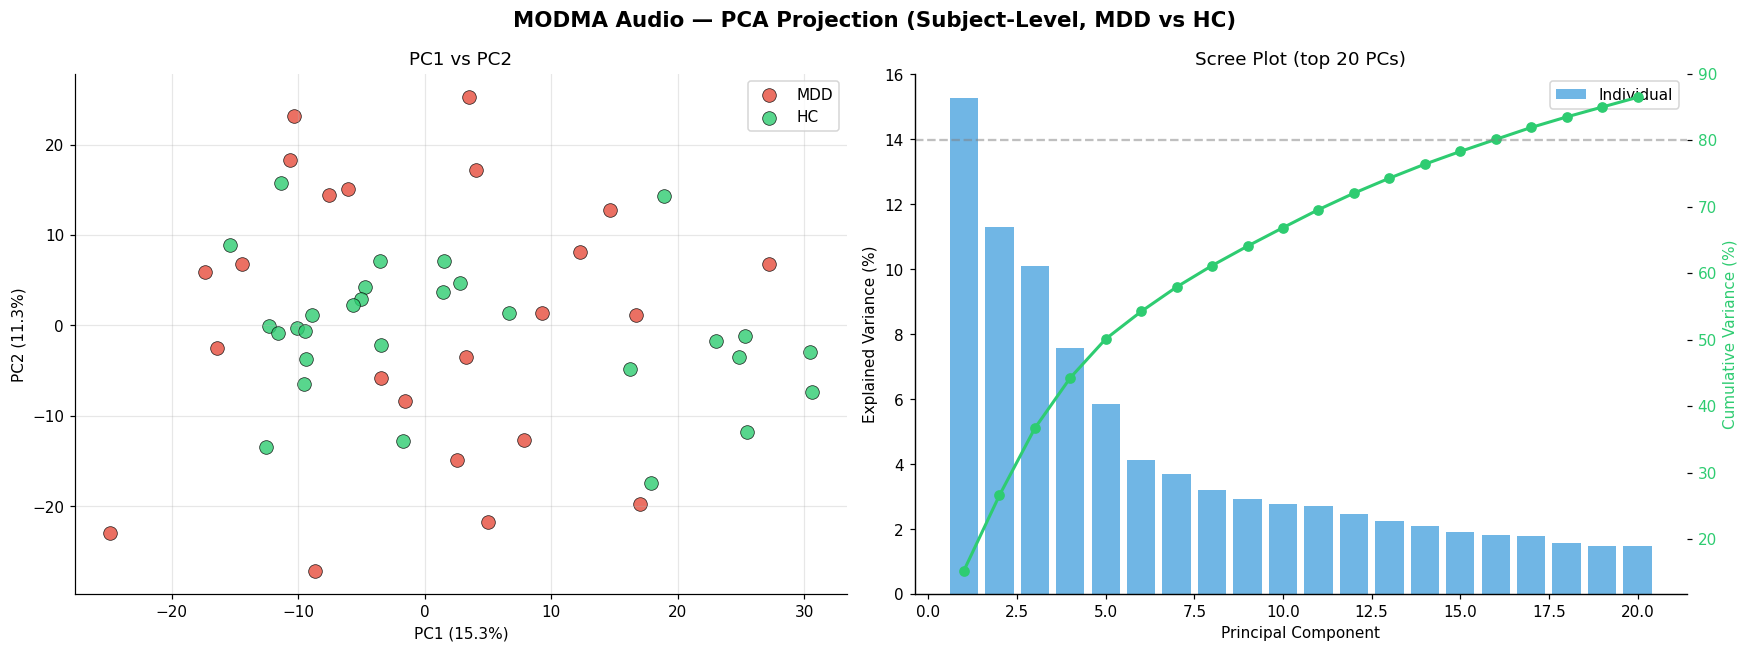


PCA summary:
  Components fitted         : 36
  Variance by PC1+PC2       : 26.6%
  Components for ≥80% var   : 16
✓ PCA plot saved.


In [29]:

# ─ Color palette ──────────────────────────────────────────────────────────────
MDD_COLOR = "#e74c3c"
HC_COLOR  = "#2ecc71"
PALETTE   = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]

# ─ Prepare scaled feature matrix for entire dataset ───────────────────────────
X_all_scaled = pd.DataFrame(
    scaler.transform(feat_matrix), 
    index=feat_matrix.index, 
    columns=feat_matrix.columns
)
train_mask = (subj_agg["split"] == "train").values

# ─ Fit PCA on training subjects only ─────────────────────────────────────────
n_train = int(train_mask.sum())
n_pca   = min(50, n_train)           # cap at n_train so PCA is valid
pca_50  = PCA(n_components=n_pca, random_state=RANDOM_SEED)
pca_50.fit(X_all_scaled.values[train_mask])
X_pca   = pca_50.transform(X_all_scaled.values)

labels_all = subj_agg["label"].values
groups_all = subj_agg["group"].values

# ─ 2D scatter (PC1 vs PC2) ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("MODMA Audio — PCA Projection (Subject-Level, MDD vs HC)", fontsize=14, fontweight="bold")

for lbl, grp, clr in [(1, "MDD", MDD_COLOR), (0, "HC", HC_COLOR)]:
    mask = labels_all == lbl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=clr, label=grp, alpha=0.8, s=80, edgecolors="k", linewidths=0.5)

axes[0].set_xlabel(f"PC1 ({pca_50.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_50.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PC1 vs PC2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ─ Explained variance scree plot ─────────────────────────────────────────────
n_show = min(20, n_pca)
cumvar = np.cumsum(pca_50.explained_variance_ratio_[:n_show]) * 100
axes[1].bar(range(1, n_show+1), pca_50.explained_variance_ratio_[:n_show] * 100,
            color=PALETTE[0], alpha=0.7, label="Individual")
ax2 = axes[1].twinx()
ax2.plot(range(1, n_show+1), cumvar, "o-", color=PALETTE[2], linewidth=2, label="Cumulative")
ax2.set_ylabel("Cumulative Variance (%)", color=PALETTE[2])
ax2.axhline(80, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
ax2.tick_params(axis="y", labelcolor=PALETTE[2])
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Explained Variance (%)")
axes[1].set_title(f"Scree Plot (top {n_show} PCs)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUT_DIR / "modma_audio_pca.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPCA summary:")
print(f"  Components fitted         : {n_pca}")
print(f"  Variance by PC1+PC2       : {(pca_50.explained_variance_ratio_[:2].sum()*100):.1f}%")
cumvar_full = np.cumsum(pca_50.explained_variance_ratio_) * 100
n80 = int(np.searchsorted(cumvar_full, 80.0)) + 1
print(f"  Components for ≥80% var   : {n80}")
print("✓ PCA plot saved.")


## Section 23 — Final Feature Matrix Inspection

In [30]:
# ── Feature count by group ────────────────────────────────────────────────────
modality_groups = {
    "MFCC (base)"       : [c for c in subj_feat_cols if c.startswith("mfcc_") and "delta" not in c],
    "MFCC (delta)"      : [c for c in subj_feat_cols if "mfcc_delta" in c],
    "Chroma"            : [c for c in subj_feat_cols if c.startswith("chroma_")],
    "Mel spectrogram"   : [c for c in subj_feat_cols if c.startswith("mel_")],
    "Spectral"          : [c for c in subj_feat_cols if c.startswith("spectral_")],
    "Rhythm / Onset"    : [c for c in subj_feat_cols if c.startswith("tempo_") or c.startswith("onset_")],
    "ZCR"               : [c for c in subj_feat_cols if c.startswith("zcr_")],
    "RMS energy"        : [c for c in subj_feat_cols if c.startswith("rms_")],
    "Duration"          : [c for c in subj_feat_cols if c.startswith("duration_")],
}

print("=" * 60)
print("  MODMA Audio — Final Feature Matrix Summary")
print("=" * 60)
print(f"  {'Feature Group':<22}  {'# Features':>10}")
print("-" * 60)
total = 0
for grp, cols in modality_groups.items():
    print(f"  {grp:<22}  {len(cols):>10}")
    total += len(cols)
print("-" * 60)
print(f"  {'TOTAL (subject-level)':<22}  {total:>10}")
print("=" * 60)

print(f"\nFinal array shapes:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")

print(f"\nSample — first 3 train rows, first 8 features (scaled):")
df_sample = pd.DataFrame(X_train[:3, :8], columns=subj_feat_cols[:8])
print(df_sample.round(3).to_string(index=False))

  MODMA Audio — Final Feature Matrix Summary
  Feature Group           # Features
------------------------------------------------------------
  MFCC (base)                    400
  MFCC (delta)                   160
  Chroma                         120
  Mel spectrogram                256
  Spectral                        44
  Rhythm / Onset                   8
  ZCR                              6
  RMS energy                       6
  Duration                         2
------------------------------------------------------------
  TOTAL (subject-level)         1002

Final array shapes:
  X_train : (36, 1002)   y_train : (36,)
  X_val   : (8, 1002)     y_val   : (8,)
  X_test  : (8, 1002)    y_test  : (8,)

Sample — first 3 train rows, first 8 features (scaled):
 duration_s_segmean  duration_s_segstd  mfcc_01_mean_segmean  mfcc_01_mean_segstd  mfcc_01_std_segmean  mfcc_01_std_segstd  mfcc_01_min_segmean  mfcc_01_min_segstd
            -0.5960             0.1620               -1.1760  

## Section 24 — Export Final Datasets to Disk

In [31]:
import os as _os

# ── 24-A  NumPy arrays (train/val/test — scaled, float32) ────────────────────
np.save(OUT_DIR / "modma_audio_X_train.npy",  X_train)
np.save(OUT_DIR / "modma_audio_X_val.npy",    X_val)
np.save(OUT_DIR / "modma_audio_X_test.npy",   X_test)
np.save(OUT_DIR / "modma_audio_y_train.npy",  y_train)
np.save(OUT_DIR / "modma_audio_y_val.npy",    y_val)
np.save(OUT_DIR / "modma_audio_y_test.npy",   y_test)

# ── 24-B  Feature column names list ──────────────────────────────────────────
feat_col_path = OUT_DIR / "modma_audio_feature_cols.txt"
with open(feat_col_path, "w") as f:
    f.write("\n".join(subj_feat_cols))

# ── 24-C  Full raw (unscaled) subject-level CSV ───────────────────────────────
raw_csv_path = OUT_DIR / "modma_audio_features_raw.csv"
subj_agg.to_csv(raw_csv_path, index=False, float_format="%.6f")

# ── 24-D  Scaled subject-level CSV ───────────────────────────────────────────
scaled_df = subj_agg[["subject_id", "group", "label", "split"]].copy()
scaled_X_all = scaler.transform(subj_agg[subj_feat_cols].values.astype(np.float64))
for i, col in enumerate(subj_feat_cols):
    scaled_df[col] = scaled_X_all[:, i]
scaled_csv_path = OUT_DIR / "modma_audio_features_scaled.csv"
scaled_df.to_csv(scaled_csv_path, index=False, float_format="%.6f")

# ── 24-E  Per-file feature CSV (raw, unscaled — all 1508 rows) ───────────────
file_feat_csv = OUT_DIR / "modma_audio_file_features.csv"
file_features_df.drop(columns=["file_path"], errors="ignore").to_csv(
    file_feat_csv, index=False, float_format="%.6f"
)

# ── 24-F  Subject split mapping ───────────────────────────────────────────────
# (already saved earlier — just confirm)
split_csv = OUT_DIR / "modma_audio_subject_splits.csv"

# ── 24-G  Fitted scaler ───────────────────────────────────────────────────────
scaler_path = OUT_DIR / "modma_audio_scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

# ── 24-H  ANOVA feature ranking CSV ──────────────────────────────────────────
anova_df.to_csv(OUT_DIR / "modma_audio_feature_ranking.csv", index=False)

# ── Summary printout ──────────────────────────────────────────────────────────
files_saved = [
    ("modma_audio_X_train.npy",        f"{X_train.shape}  float32"),
    ("modma_audio_X_val.npy",          f"{X_val.shape}    float32"),
    ("modma_audio_X_test.npy",         f"{X_test.shape}   float32"),
    ("modma_audio_y_train.npy",        f"{y_train.shape}  int32  labels"),
    ("modma_audio_y_val.npy",          f"{y_val.shape}    int32  labels"),
    ("modma_audio_y_test.npy",         f"{y_test.shape}   int32  labels"),
    ("modma_audio_feature_cols.txt",   f"{len(subj_feat_cols)} feature names"),
    ("modma_audio_features_raw.csv",   f"{subj_agg.shape} unscaled subject features"),
    ("modma_audio_features_scaled.csv",f"{scaled_df.shape} scaled subject features"),
    ("modma_audio_file_features.csv",  f"{file_features_df.shape} per-file features"),
    ("modma_audio_subject_splits.csv", "subject → split mapping"),
    ("modma_audio_scaler.pkl",         "StandardScaler fitted on train"),
    ("modma_audio_feature_ranking.csv",f"{len(anova_df)} features ranked by ANOVA F"),
]

print("=" * 72)
print(f"  Files saved to: {OUT_DIR}")
print("=" * 72)
for fname, desc in files_saved:
    fpath  = OUT_DIR / fname
    exists = "✓" if fpath.exists() else "✗"
    size   = f"{fpath.stat().st_size/1024:.1f} KB" if fpath.exists() else "N/A"
    print(f"  {exists}  {fname:<42}  {size:<12}  {desc}")

  Files saved to: e:\Group-6-DS-and-AI-Lab-Project\processed_data\modma_audio
  ✓  modma_audio_X_train.npy                     141.0 KB      (36, 1002)  float32
  ✓  modma_audio_X_val.npy                       31.4 KB       (8, 1002)    float32
  ✓  modma_audio_X_test.npy                      31.4 KB       (8, 1002)   float32
  ✓  modma_audio_y_train.npy                     0.3 KB        (36,)  int32  labels
  ✓  modma_audio_y_val.npy                       0.2 KB        (8,)    int32  labels
  ✓  modma_audio_y_test.npy                      0.2 KB        (8,)   int32  labels
  ✓  modma_audio_feature_cols.txt                22.5 KB       1002 feature names
  ✓  modma_audio_features_raw.csv                506.3 KB      (52, 1006) unscaled subject features
  ✓  modma_audio_features_scaled.csv             508.7 KB      (52, 1006) scaled subject features
  ✓  modma_audio_file_features.csv               7348.0 KB     (1503, 506) per-file features
  ✓  modma_audio_subject_splits.csv           

## Section 25 — Reload Snippet & Integration Guide

How to load these files in the model training notebook:

```python
import numpy as np, pickle
from pathlib import Path

OUT = Path("processed_data/modma_audio")

# Scaled arrays (ready for model — float32)
X_train = np.load(OUT / "modma_audio_X_train.npy")   # (n_train, n_features) float32
X_val   = np.load(OUT / "modma_audio_X_val.npy")
X_test  = np.load(OUT / "modma_audio_X_test.npy")

# Binary labels (MDD=1, HC=0 — int32)
y_train = np.load(OUT / "modma_audio_y_train.npy")
y_val   = np.load(OUT / "modma_audio_y_val.npy")
y_test  = np.load(OUT / "modma_audio_y_test.npy")

# Feature names (for SHAP / interpretability)
with open(OUT / "modma_audio_feature_cols.txt") as f:
    feat_cols = f.read().splitlines()

# Scaler — to inverse-transform predictions or scale new data
with open(OUT / "modma_audio_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
```

### Feature group indices for selective fusion
```python
mfcc_idx     = [i for i,c in enumerate(feat_cols) if c.startswith("mfcc_") and "delta" not in c]
delta_idx    = [i for i,c in enumerate(feat_cols) if "mfcc_delta" in c]
chroma_idx   = [i for i,c in enumerate(feat_cols) if c.startswith("chroma_")]
mel_idx      = [i for i,c in enumerate(feat_cols) if c.startswith("mel_")]
spectral_idx = [i for i,c in enumerate(feat_cols) if c.startswith("spectral_")]
rhythm_idx   = [i for i,c in enumerate(feat_cols) if c.startswith("tempo_") or c.startswith("onset_")]
zcr_idx      = [i for i,c in enumerate(feat_cols) if c.startswith("zcr_")]
rms_idx      = [i for i,c in enumerate(feat_cols) if c.startswith("rms_")]

X_mfcc_only  = X_train[:, mfcc_idx + delta_idx]          # for MFCC ablation
X_spectral   = X_train[:, mel_idx + spectral_idx]         # for spectral ablation
```

### Dataset summary
| Property | Value |
|---|---|
| Subjects | 52 (MDD=23, HC=29) |
| Audio files | 1,508 (29 per subject) |
| Per-file features | ~488 |
| Subject-level features | ~976 (mean+std across 29 segments) |
| Train / Val / Test | ~36 / ~8 / ~8 subjects |
| Label encoding | MDD=1, HC=0 |
| Scaling | StandardScaler (fit on train only) |